In [2]:
import pandas as pd
from pandas import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib.ticker import MultipleLocator

# Deciduous

In [39]:
deciduous_dogs = pd.read_excel('../data/deciduousdentition_statistics_tables_220404.xlsx', index_col=0, sheet_name='dog characteristics')
deciduous_teeth = pd.read_excel('../data/deciduousdentition_statistics_tables_220404.xlsx', index_col=0, sheet_name='data')

## Dogs

### Overzicht volledige dataset

Overzicht van de eerste vijf rijen.

Opvallend:
- Een Unnamed kolom (bevat 2 opmerkingen over pups die kruising zijn met griffon) --> weglaten
- NaN waarde in LITTER
- . in SEX

In [40]:
deciduous_dogs.head()

,SEX,BREED,LITTER,BREED SIZE,SKULL TYPE,BREED CLADE,RELIABILITY (1/2),Unnamed: 8
DOG,,,,,,,,
1,F,Akita Inu,Single,Large,Meso,A,2,NaN
2,M,American Staffordshire Terrier,Single,Large,Meso,W,2,NaN
3,.,Australian Cattle Dog,Single,Medium,Meso,T,1,NaN
4,M,Australian Shepherd,Aussie 1,Medium,Meso,T,1,NaN
5,F,Australian Shepherd,NaN,Medium,Meso,T,1,NaN


In [41]:
deciduous_dogs.drop('Unnamed: 8', axis=1, inplace=True)

1001 pups werden opgevolgd in de studie

In [42]:
deciduous_dogs.shape

(1001, 7)

LITTER is enige kolom die null waarden bevat. Nader bekeken werd telkens maar de litter bij de eerste pup ingevuld, degene die erop volgen behoren dezelfde litter. Dit kan dus opgevuld worden.

In [43]:
deciduous_dogs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1001 entries, 1 to 1001
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SEX                1001 non-null   object
 1   BREED              1001 non-null   object
 2   LITTER             269 non-null    object
 3   BREED SIZE         1001 non-null   object
 4   SKULL TYPE         1001 non-null   object
 5   BREED CLADE        1001 non-null   object
 6   RELIABILITY (1/2)  1001 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 62.6+ KB


In [44]:
deciduous_dogs['LITTER'] = deciduous_dogs['LITTER'].fillna(method='ffill')

Opvallend bij describe:
- SEX heeft 8 unieke waarden
- 53 rassen werden opgevolgd waarvan Pomeranian populairst
- Small BREED SIZE bijna helft van de dataset

In [45]:
deciduous_dogs.describe(include=["object"])

,SEX,BREED,LITTER,BREED SIZE,SKULL TYPE,BREED CLADE
count,1001,1001,1001,1001,1001,1001
unique,8,53,197,4,6,20
top,F,Pomeranian,Single,Small,Meso,Q
freq,489,79,75,498,550,102


### SEX

De SEX kolom bevat meerdere waarden. Die omzetten naar de drie toegelaten waarden: F, M, X

['F' 'M' '.' 'V' ' V' '?' 'F?' 'F ']


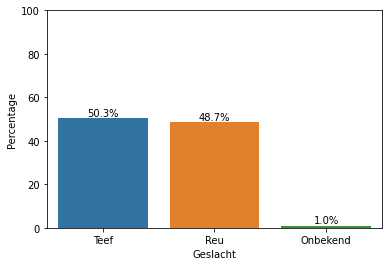

F    504
M    487
X     10
Name: SEX, dtype: int64

In [46]:
print(deciduous_dogs["SEX"].unique())

deciduous_dogs['SEX']=deciduous_dogs['SEX'].replace(['V', ' V', 'F ', 'F?'], 'F')
deciduous_dogs['SEX']=deciduous_dogs['SEX'].replace(['.', '?'], 'X')

# Normalize the counts to percentages
total_count = len(deciduous_dogs)
percentage = deciduous_dogs['SEX'].value_counts(normalize=True) * 100

# Create a percentage-based bar plot
plot = sns.barplot(x=percentage.index, y=percentage.values)
plot.set_xlabel('Geslacht')
plot.set_ylabel('Percentage')
plot.set_xticklabels(['Teef', 'Reu', 'Onbekend'])
plot.set(ylim=(0, 100))  # Percentage axis ranges from 0 to 100

# Add percentage labels above the bars
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

deciduous_dogs["SEX"].value_counts()

### BREED

In [47]:
print(deciduous_dogs["BREED"].unique())

print(deciduous_dogs['BREED'].value_counts()[:10])

# Create the treemap
fig = px.treemap(data_frame=deciduous_dogs, path=['BREED'], width=1200, height=700)
# Calculate the percentage dynamically for each segment
fig.update_traces(
    texttemplate="%{label}<br>%{value} (%{percentEntry:.2%})",
    textinfo="label+value"
)
# Adjust layout and font size
fig.update_layout(margin=dict(t=0, l=0, r=0, b=25))
fig.update_traces(textfont_size=16)
# Show the plot
fig.show()

['Akita Inu' 'American Staffordshire Terrier' 'Australian Cattle Dog'
 'Australian Shepherd' 'Beagle' 'Bernese mountain dog' 'Bichon frise'
 'Border collie' ' Bull terrier MINIATURE'
 'Cavalier King Charles Spaniel ' 'Chinese crested dog' 'Chihuahua'
 'Drentse Patrijs' 'Dutch shepherd' 'English bulldog'
 'English cocker spaniel' 'English springer spaniel' 'French bulldog '
 'German shepherd' 'Golden retriever' 'Gordon Setter' 'Great Dane'
 'Havaneze' 'Irish setter' 'Jack russell terrier' 'Korean Jindo'
 'Labradoodle' 'Labrador' 'Lhasa apso' 'Malchi' 'Malinois' 'Maltese '
 'Neapolitan mastiff' 'Newfoundland' 'Pomeranian ' 'Pomski'
 'Poodle miniature' 'Pug' 'Schnauzer MINIATURE' 'Scottish terrier'
 'Sheltie' 'Shiba inu' 'Shi Tzu' 'Siberian husky' 'Small Munsterlander'
 'Soft coated wheaten terrier' 'Stabyhoun' 'Staffordshire bull terrier'
 'Teckel (= Dachshund) ' 'Tibetan mastiff' 'Welsh Corgi Cardigan'
 'Whippet' 'Yorkshire terrier']
Pomeranian              79
Bernese mountain dog    64

### LITTER

In [48]:
print(deciduous_dogs["LITTER"].unique())
print(deciduous_dogs['LITTER'].value_counts()[:10])

# pups die als enige deel uitmaken v nest --> single maken
s = deciduous_dogs['LITTER'].value_counts()
deciduous_dogs.loc[deciduous_dogs['LITTER'].isin(s[s==1].index), 'LITTER'] = 'Single'

litter_counts = deciduous_dogs.groupby(['BREED', 'LITTER']).size().reset_index(name='count')
breed_totals = litter_counts.groupby('BREED')['count'].sum().reset_index(name='total')
litter_counts = litter_counts.merge(breed_totals, on='BREED')
litter_counts['percentage'] = (litter_counts['count'] / litter_counts['total']) * 100

fig = px.treemap(litter_counts, path=['BREED', 'LITTER'], values='count', width=1200, height=700, hover_data=['percentage'])
fig.data[0].textinfo = 'label+value+percent entry'
fig.data[0].texttemplate = '%{label}<br>%{value}<br>%{customdata[0]:.1f}%'
fig.update_traces(textfont_size=16)
fig.update_layout(margin=dict(t=0, l=0, r=0, b=25))
fig.show()

['Single' 'Aussie 1' 'beagle 1' 'beagle 2' 'beagle 3' 'beagle 4'
 'beagle 5' 'beagle 6' 'beagle 7' 'Bernese 1' 'Bernese 2' 'Bernese 3'
 'Bernese 4' 'Bernese 5' 'Bernese 6' 'Bernese 7' 'Bernese 8' 'Bernese 9'
 'Bernese 10' 'Bernese 11' 'Bichon 1' 'BC 1' 'BC 2' 'BC 12' 'BC HH1'
 'Bull T 1' 'CKCH 1' 'CKCH 2' 'CKCH 3' 'CKCH 4' 'CKCH 5'
 'Chinese Crested 1' 'Chihua 1' 'Chihua 2' 'Chihua 3' 'Chihua 4'
 'Chihua 5' 'Chihua 6' 'Chihua 7' 'Chihua 8' 'Chihua 9' 'Drent 1'
 'Drent 2' 'Hollandse H 1' 'Hollandse H 2' 'Hollandse H 3'
 'Engelse Bulld 1' 'Engelse cocker 1' 'Engelse cocker 2' 'ESS 3' 'ESS 4'
 'ESS 5' 'ESS 6' 'ESS 7' 'FrB 1' 'FrB 2' 'FrB 3' 'FrB 4' 'FrB 5' 'FrB 6'
 'FrB 7' 'FrB 8' 'FrB 9 ' 'FrB 10' 'oudDH 1' 'oudDH 2' 'DH 3' 'DH 4'
 'GR 14' 'GR 15' 'GR 16' 'GR 17' 'GR 18' 'GR 19' 'GR 20' 'GR 23' 'GR 25'
 'Havanezer 1' 'Havanezer 2' 'Ierse S 1' 'JR 1' 'JR 2' 'JR 3' 'JR 4'
 'JR 5' 'JR 7' 'JR 8' 'Jindo 1' 'Labradoodle 1' 'Labradoodle 2'
 'Labradoodle 3' 'Labradoodle 4' 'Lab 1-choco' 'Lab 3-c

### BREED SIZE

Ordening toepassen S < M < L < G

Data is niet even. Veel meer small honden dan andere groottes

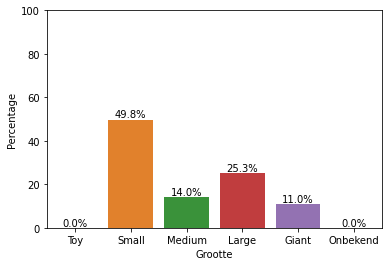

In [49]:
deciduous_dogs["BREED SIZE"].unique()

size_type = CategoricalDtype(categories=["Toy", "Small", "Medium", "Large", "Giant", "Onbekend"], ordered=True)
deciduous_dogs["BREED SIZE"] = deciduous_dogs["BREED SIZE"].astype(size_type)

total_count = len(deciduous_dogs)
percentage = deciduous_dogs['BREED SIZE'].value_counts(normalize=True) * 100

plot = sns.barplot(x=percentage.index, y=percentage.values, order=size_type.categories)
plot.set_xlabel('Grootte')
plot.set_ylabel('Percentage')
plot.set(ylim=(0, 100)) 
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

### SKULL TYPE

Data is niet even. Meso klasse overheerst

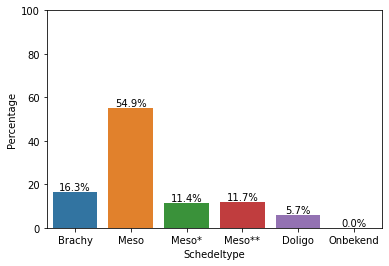

In [50]:
deciduous_dogs["SKULL TYPE"].unique()
deciduous_dogs['SKULL TYPE']=deciduous_dogs['SKULL TYPE'].replace(['doligo'], 'Doligo')

skull_type = CategoricalDtype(categories=["Brachy", "Meso", "Meso*", "Meso**", "Doligo", "Onbekend"], ordered=True)
deciduous_dogs["SKULL TYPE"] = deciduous_dogs["SKULL TYPE"].astype(skull_type)

total_count = len(deciduous_dogs)
percentage = deciduous_dogs['SKULL TYPE'].value_counts(normalize=True) * 100

plot = sns.barplot(x=percentage.index, y=percentage.values, order=skull_type.categories)
plot.set_xlabel('Schedeltype')
plot.set_ylabel('Percentage')
plot.set(ylim=(0, 100)) 
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

### SKULL TYPE & BREED SIZE
- Alle vier de sizes bij Meso
- Voornamelijk Small en Giant bij Brachy
- Enkel Small bij Meso**
- Voornamelijk Large bij Meso*
- Voornamelijk Small bij Doligo
- Giant enkel bij Meso en Brachy
- Medium enkel bij Meso en Meso*

(-0.75, 5.75)

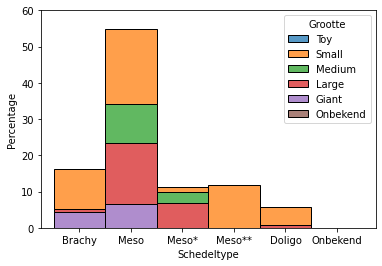

In [51]:
plot=sns.histplot(binwidth=1,
            x="SKULL TYPE",
            hue="BREED SIZE",
            data=deciduous_dogs,
            stat="percent",
            multiple="stack")
plot.set_xlabel('Schedeltype')
plot.set_ylabel('Percentage')
plot.set_ylim(0,60)
sns.move_legend(plot, title='Grootte', loc='best')

current_xlim = plot.get_xlim()
plot.set_xlim(current_xlim[0], current_xlim[1] + 1)


### BREED CLADE

['A' 'W' 'T' 'O' 'V' 'H' 'P' 'I' '.' 'M' 'Q' 'R' 'X' 'L' 'B' 'S' 'E' 'F'
 'D' 'Y']
Q    102
E     91
L     86
A     86
H     77
O     71
P     69
W     69
V     64
I     45
Name: BREED CLADE, dtype: int64


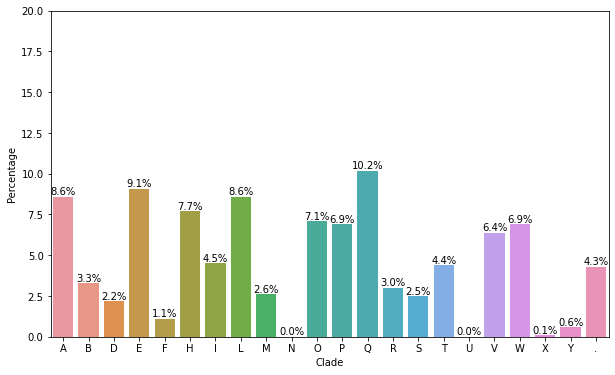

In [52]:
print(deciduous_dogs["BREED CLADE"].unique())
print(deciduous_dogs['BREED CLADE'].value_counts()[:10])

clade_alfa = CategoricalDtype(categories=["A", "B", "D", "E", "F", "H", "I", "L", "M", "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "."], ordered=True)
deciduous_dogs["BREED CLADE"] = deciduous_dogs["BREED CLADE"].astype(clade_alfa)

# barplot
total_count = len(deciduous_dogs)
percentage = deciduous_dogs['BREED CLADE'].value_counts(normalize=True) * 100
plt.figure(figsize=(10, 6))
plot = sns.barplot(x=percentage.index, y=percentage.values, order=clade_alfa.categories)
plot.set_xlabel('Clade')
plot.set_ylabel('Percentage')
plot.set(ylim=(0, 20)) 
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

#grid
clade_counts = deciduous_dogs.groupby(['BREED CLADE', 'BREED']).size().reset_index(name='count')
breed_totals = clade_counts.groupby('BREED CLADE')['count'].sum().reset_index(name='total')
clade_counts = clade_counts.merge(breed_totals, on='BREED CLADE')
clade_counts['percentage'] = (clade_counts['count'] / clade_counts['total']) * 100

fig = px.treemap(clade_counts, path=['BREED CLADE', 'BREED'], values='count', width=1200, height=700, hover_data=['percentage'])
fig.data[0].textinfo = 'label+value+percent entry'
fig.data[0].texttemplate = '%{label}<br>%{value}<br>%{customdata[0]:.1f}%'
fig.update_traces(textfont_size=16)
fig.update_layout(margin=dict(t=0, l=0, r=0, b=25))
fig.show()

### RELIABILITY

Completely reliable (1) komt veel meer voor

reliability: if an outlyer belongs to group 2, this might mean that age was not correct --> onderzoeken!

1    920
2     81
Name: RELIABILITY (1/2), dtype: int64
[2 1]


<AxesSubplot:xlabel='RELIABILITY (1/2)', ylabel='count'>

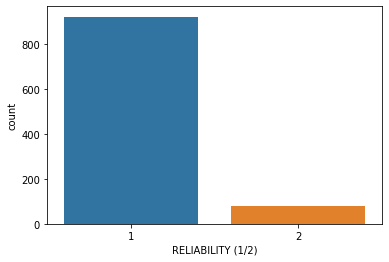

In [53]:
print(deciduous_dogs['RELIABILITY (1/2)'].value_counts())

print(deciduous_dogs['RELIABILITY (1/2)'].unique())

sns.countplot(data=deciduous_dogs, x="RELIABILITY (1/2)")

## Teeth

### Overzicht volledige dataset

Per hond meerdere rijen --> observatie van iedere tand staat in 2 rijen (1 voor eerste DEVELOPM STAGE en 1 voor tweede)

In [17]:
deciduous_teeth.head()

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
1,601,MAX,L,1,1,.,.,.
1,601,MAX,L,1,2,.,63,0
1,501,MAX,R,1,1,.,.,.
1,501,MAX,R,1,2,.,63,0
1,602,MAX,L,2,1,.,.,.


In [18]:
deciduous_teeth.shape

(56056, 8)

Geen null waarden

In [19]:
deciduous_teeth.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56056 entries, 1 to 1001
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   TOOTH NUMBER    56056 non-null  int64 
 1   MAX/MAND        56056 non-null  object
 2   SIDE (L/R)      56056 non-null  object
 3   POSITION        56056 non-null  int64 
 4   DEVELOPM STAGE  56056 non-null  int64 
 5   LOWER           56056 non-null  object
 6   UPPER           56056 non-null  object
 7   SENS            56056 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.8+ MB


Opvallende bij describe:
- Meest werden MAX & L opgevolgd (combo onderzoeken)
- LOWER, UPPER & SENS zijn objecten en geen integers --> . vervangen door NaN?

In [20]:
deciduous_teeth.describe(include=["object"])

,MAX/MAND,SIDE (L/R),LOWER,UPPER,SENS
count,56056,56056,56056,56056,56056
unique,2,2,88,90,5
top,MAX,L,.,.,0
freq,28028,28028,36654,23384,20176


### TOOTH NUMBER
= tridian nr --> mss beter om hieruit meerdere features te extracten (zie uitleg in excel) --> is al gdn

van iedere hond wordt iedere tand voor de twee stages opgevolgd

In [21]:
deciduous_teeth["TOOTH NUMBER"].value_counts()

601    2002
501    2002
708    2002
807    2002
707    2002
806    2002
706    2002
804    2002
704    2002
803    2002
703    2002
802    2002
702    2002
801    2002
701    2002
508    2002
608    2002
507    2002
607    2002
506    2002
606    2002
504    2002
604    2002
503    2002
603    2002
502    2002
602    2002
808    2002
Name: TOOTH NUMBER, dtype: int64

### MAX/MAND
omzetten nr ordinaal?

In [22]:
deciduous_teeth["MAX/MAND"].value_counts()

MAX     28028
MAND    28028
Name: MAX/MAND, dtype: int64

### SIDE (L/R)
omzetten nr ordinaal?

In [23]:
deciduous_teeth["SIDE (L/R)"].value_counts()

L    28028
R    28028
Name: SIDE (L/R), dtype: int64

### POSITION

5 niet bij deciduous, want komt enkel in permanent gebit voor

In [24]:
deciduous_teeth["POSITION"].value_counts()

1    8008
2    8008
3    8008
4    8008
6    8008
7    8008
8    8008
Name: POSITION, dtype: int64

### DEVELOPMENT STAGE

In [25]:
deciduous_teeth["DEVELOPM STAGE"].value_counts()

1    28028
2    28028
Name: DEVELOPM STAGE, dtype: int64

### LOWER

In [54]:
deciduous_teeth["LOWER"]=deciduous_teeth["LOWER"].replace('.', np.nan)

Wordt nog steeds als object gezien

In [55]:
deciduous_teeth["LOWER"].describe()

count     19402
unique       87
top          29
freq       1112
Name: LOWER, dtype: int64

Bevat ook ' '

In [56]:
deciduous_teeth["LOWER"].unique()

array([nan, 56, 25, 28, 31, 24, 21, 39, 52, 46, 30, 26, 27, 33, 18, 20,
       40, 29, 23, 37, 51, 47, 19, 41, 22, 42, 53, 14, 15, 34, 17, 38, 44,
       48, 35, 32, 16, 36, 50, 45, 43, 49, 55, 67, 88, 62, 60, 59, 58, 57,
       64, 82, 80, 11, 54, 90, 78, 71, 63, 61, 66, 69, 84, 100, 98, 73,
       113, 87, 79, 72, 76, 70, 74, 94, 77, 93, 68, 75, 83, 81, 95, 89,
       ' ', 65, 96, 323, 85, 92], dtype=object)

In [57]:
deciduous_teeth["LOWER"]=deciduous_teeth["LOWER"].replace(' ', np.nan)
deciduous_teeth["LOWER"]=pd.to_numeric(deciduous_teeth["LOWER"])

Er zijn honden met alle LOWER values ingevuld en ook honden met alle LOWER values NaN

Meer honden met LOWER NaN te zien aan gem en %

In [58]:
deciduous_teeth["LOWER"].isnull().groupby(deciduous_teeth.index).sum().astype(int).describe()

count    1001.000000
mean       36.618382
std        17.929535
min         0.000000
25%        22.000000
50%        38.000000
75%        55.000000
max        56.000000
Name: LOWER, dtype: float64

max = 323 --> is dit juist?

In [59]:
deciduous_teeth["LOWER"].describe()

count    19401.000000
mean        34.026700
std         12.612468
min         11.000000
25%         25.000000
50%         31.000000
75%         41.000000
max        323.000000
Name: LOWER, dtype: float64

Is right censoring met heel hoge LOWER grens --> correct?

In [60]:
deciduous_teeth[deciduous_teeth["LOWER"]==323]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
935,701,MAND,L,1,1,323.0,.,2


vgl met andere waarden --> LOWER vaak 32 --> wss typfout (=> 32 of 33?)

In [61]:
deciduous_teeth[deciduous_teeth.index==935]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
935,601,MAX,L,1,1,NaN,.,.
935,601,MAX,L,1,2,NaN,31,0
935,501,MAX,R,1,1,NaN,.,.
935,501,MAX,R,1,2,NaN,31,0
935,602,MAX,L,2,1,NaN,.,.
935,602,MAX,L,2,2,NaN,31,0
935,502,MAX,R,2,1,NaN,.,.
935,502,MAX,R,2,2,NaN,31,0
935,603,MAX,L,3,1,NaN,.,.


fouten eruithalen

In [62]:
deciduous_teeth['LOWER']=deciduous_teeth['LOWER'].replace(323,32)

Mag omgewisseld bij: pup 18, 19, 21, 191, 192, 294, 563, 621, 622, 652

Pup 51: 32 vervangen door “. “

pup 178: 59 vervangen door “. “

pup 253: 34 vervangen door 31

pup 282 en 285: 37 vervangen door 30

pup 289: 32 vervangen door 24

pup 298: 45 vervangen door 38

pup 678: 57 vervangen door “.”

Pup 977: voor tand 601: 29 vervangen door 26, voor tand 602: 26 vervangen door 29

TYPES CENSORING UPDATEN

178	708	MAND	L	8	2	59.0	58.0	3

178	808	MAND	R	8	2	59.0	58.0	3

In [64]:
deciduous_teeth["UPPER"]=deciduous_teeth["UPPER"].replace('.', np.nan)
deciduous_teeth["UPPER"]=pd.to_numeric(deciduous_teeth["UPPER"])

In [65]:
deciduous_teeth.loc[(deciduous_teeth.index == 51) & (deciduous_teeth['TOOTH NUMBER'] == 607) & (deciduous_teeth['DEVELOPM STAGE'] == 1), 'LOWER'] = np.nan
deciduous_teeth.loc[(deciduous_teeth.index == 51) & (deciduous_teeth['TOOTH NUMBER'] == 607) & (deciduous_teeth['DEVELOPM STAGE'] == 1), 'SENS'] = 0
deciduous_teeth.loc[(deciduous_teeth.index == 51) & (deciduous_teeth['TOOTH NUMBER'] == 702) & (deciduous_teeth['DEVELOPM STAGE'] == 1), 'LOWER'] = np.nan
deciduous_teeth.loc[(deciduous_teeth.index == 51) & (deciduous_teeth['TOOTH NUMBER'] == 702) & (deciduous_teeth['DEVELOPM STAGE'] == 1), 'SENS'] = 0
deciduous_teeth.loc[(deciduous_teeth.index == 178) & (deciduous_teeth['TOOTH NUMBER'] == 708) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = np.nan
deciduous_teeth.loc[(deciduous_teeth.index == 178) & (deciduous_teeth['TOOTH NUMBER'] == 708) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'SENS'] = 0
deciduous_teeth.loc[(deciduous_teeth.index == 178) & (deciduous_teeth['TOOTH NUMBER'] == 808) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = np.nan
deciduous_teeth.loc[(deciduous_teeth.index == 178) & (deciduous_teeth['TOOTH NUMBER'] == 808) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'SENS'] = 0
deciduous_teeth.loc[(deciduous_teeth.index == 253) & (deciduous_teeth['TOOTH NUMBER'] == 803) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 31
deciduous_teeth.loc[(deciduous_teeth.index == 282) & (deciduous_teeth['TOOTH NUMBER'] == 607) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 30
deciduous_teeth.loc[(deciduous_teeth.index == 285) & (deciduous_teeth['TOOTH NUMBER'] == 606) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 30
deciduous_teeth.loc[(deciduous_teeth.index == 289) & (deciduous_teeth['TOOTH NUMBER'] == 603) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 24
deciduous_teeth.loc[(deciduous_teeth.index == 289) & (deciduous_teeth['TOOTH NUMBER'] == 503) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 24
deciduous_teeth.loc[(deciduous_teeth.index == 298) & (deciduous_teeth['TOOTH NUMBER'] == 808) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 38
deciduous_teeth.loc[(deciduous_teeth.index == 678) & (deciduous_teeth['TOOTH NUMBER'] == 701) & (deciduous_teeth['DEVELOPM STAGE'] == 1), 'LOWER'] = np.nan
deciduous_teeth.loc[(deciduous_teeth.index == 678) & (deciduous_teeth['TOOTH NUMBER'] == 701) & (deciduous_teeth['DEVELOPM STAGE'] == 1), 'SENS'] = 0
deciduous_teeth.loc[(deciduous_teeth.index == 977) & (deciduous_teeth['TOOTH NUMBER'] == 601) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'LOWER'] = 26
deciduous_teeth.loc[(deciduous_teeth.index == 977) & (deciduous_teeth['TOOTH NUMBER'] == 602) & (deciduous_teeth['DEVELOPM STAGE'] == 2), 'UPPER'] = 29

condition = (deciduous_teeth['LOWER'] > deciduous_teeth['UPPER']) & (~deciduous_teeth.index.isin([51,178,253,282,289,298,678,977]))
deciduous_teeth.loc[condition, ['LOWER', 'UPPER']] = deciduous_teeth.loc[condition, ['UPPER', 'LOWER']].values

                  count       mean        std   min   25%   50%   75%    max
DEVELOPM STAGE                                                              
1                8897.0  31.176689  11.719002  11.0  23.0  29.0  36.0  100.0
2               10501.0  36.400057  12.524492  14.0  27.0  34.0  44.0  113.0


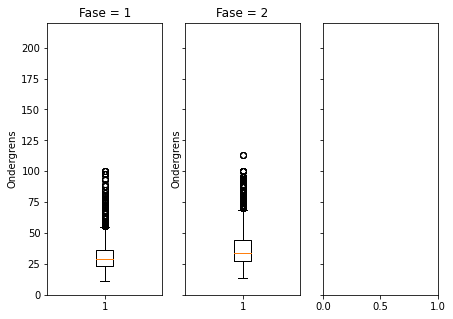

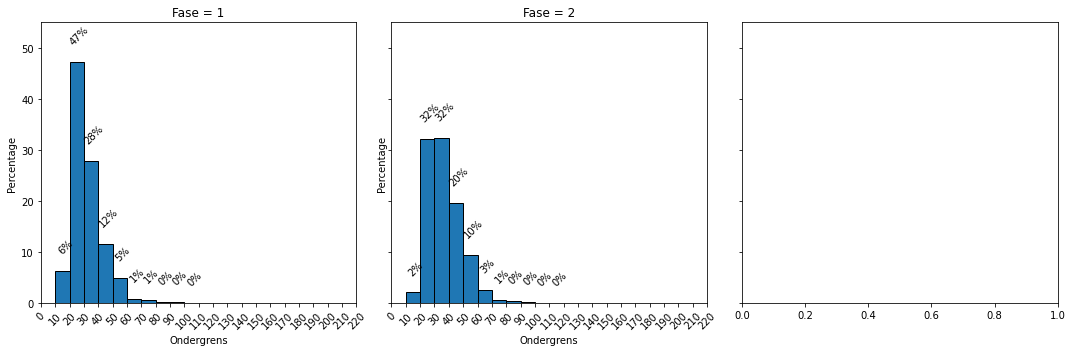

In [146]:
# group dataframe by quality values
dogs_developm_stage = deciduous_teeth[deciduous_teeth["LOWER"]<323].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["LOWER"].describe())

# create a sub plot for each quality group
fig, axes = plt.subplots(ncols=3, 
                         figsize=[7,5],
                         sharey=True)

# loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    ax.boxplot(data['LOWER'])
    ax.set_title(f"Fase = {stage}")
    ax.set_ylabel('Ondergrens')
    ax.set_ylim(0,220)



fig, axes = plt.subplots(ncols=3, 
                         figsize=[15, 5], sharey=True)
# Loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    bin_edges = range(int(min(data['LOWER'])) // 10 * 10, int(max(data['LOWER'])) // 10 * 10 + 20, 10)
    # Calculate the histogram with density=True for percentage
    counts, bins, patches = ax.hist(data['LOWER'], align='mid', edgecolor='black', bins=bin_edges, density=True)
    # Convert density to percentage
    bin_width = bins[1] - bins[0]  # Assuming bins are uniform
    counts_percent = counts * bin_width * 100  # Multiply by bin width and 100 to get percentage
    # Update the bars to represent percentages
    for patch, count in zip(patches, counts_percent):
        patch.set_height(count)
    # Annotate percentage values above the bars
    for patch in patches:
        height = patch.get_height()
        x_position = patch.get_x() + patch.get_width() / 2  # Position at the center of the bar
        ax.text(x_position+2, height + 3, f'{height:.0f}%', ha='center', va='bottom', fontsize=10,rotation=45)
    ax.set_title(f"Fase = {stage}")
    ax.set_xlabel('Ondergrens')
    ax.set_ylabel("Percentage")
    ax.set_xlim(0, 220)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(MultipleLocator(10))
plt.tight_layout()

PER TAND

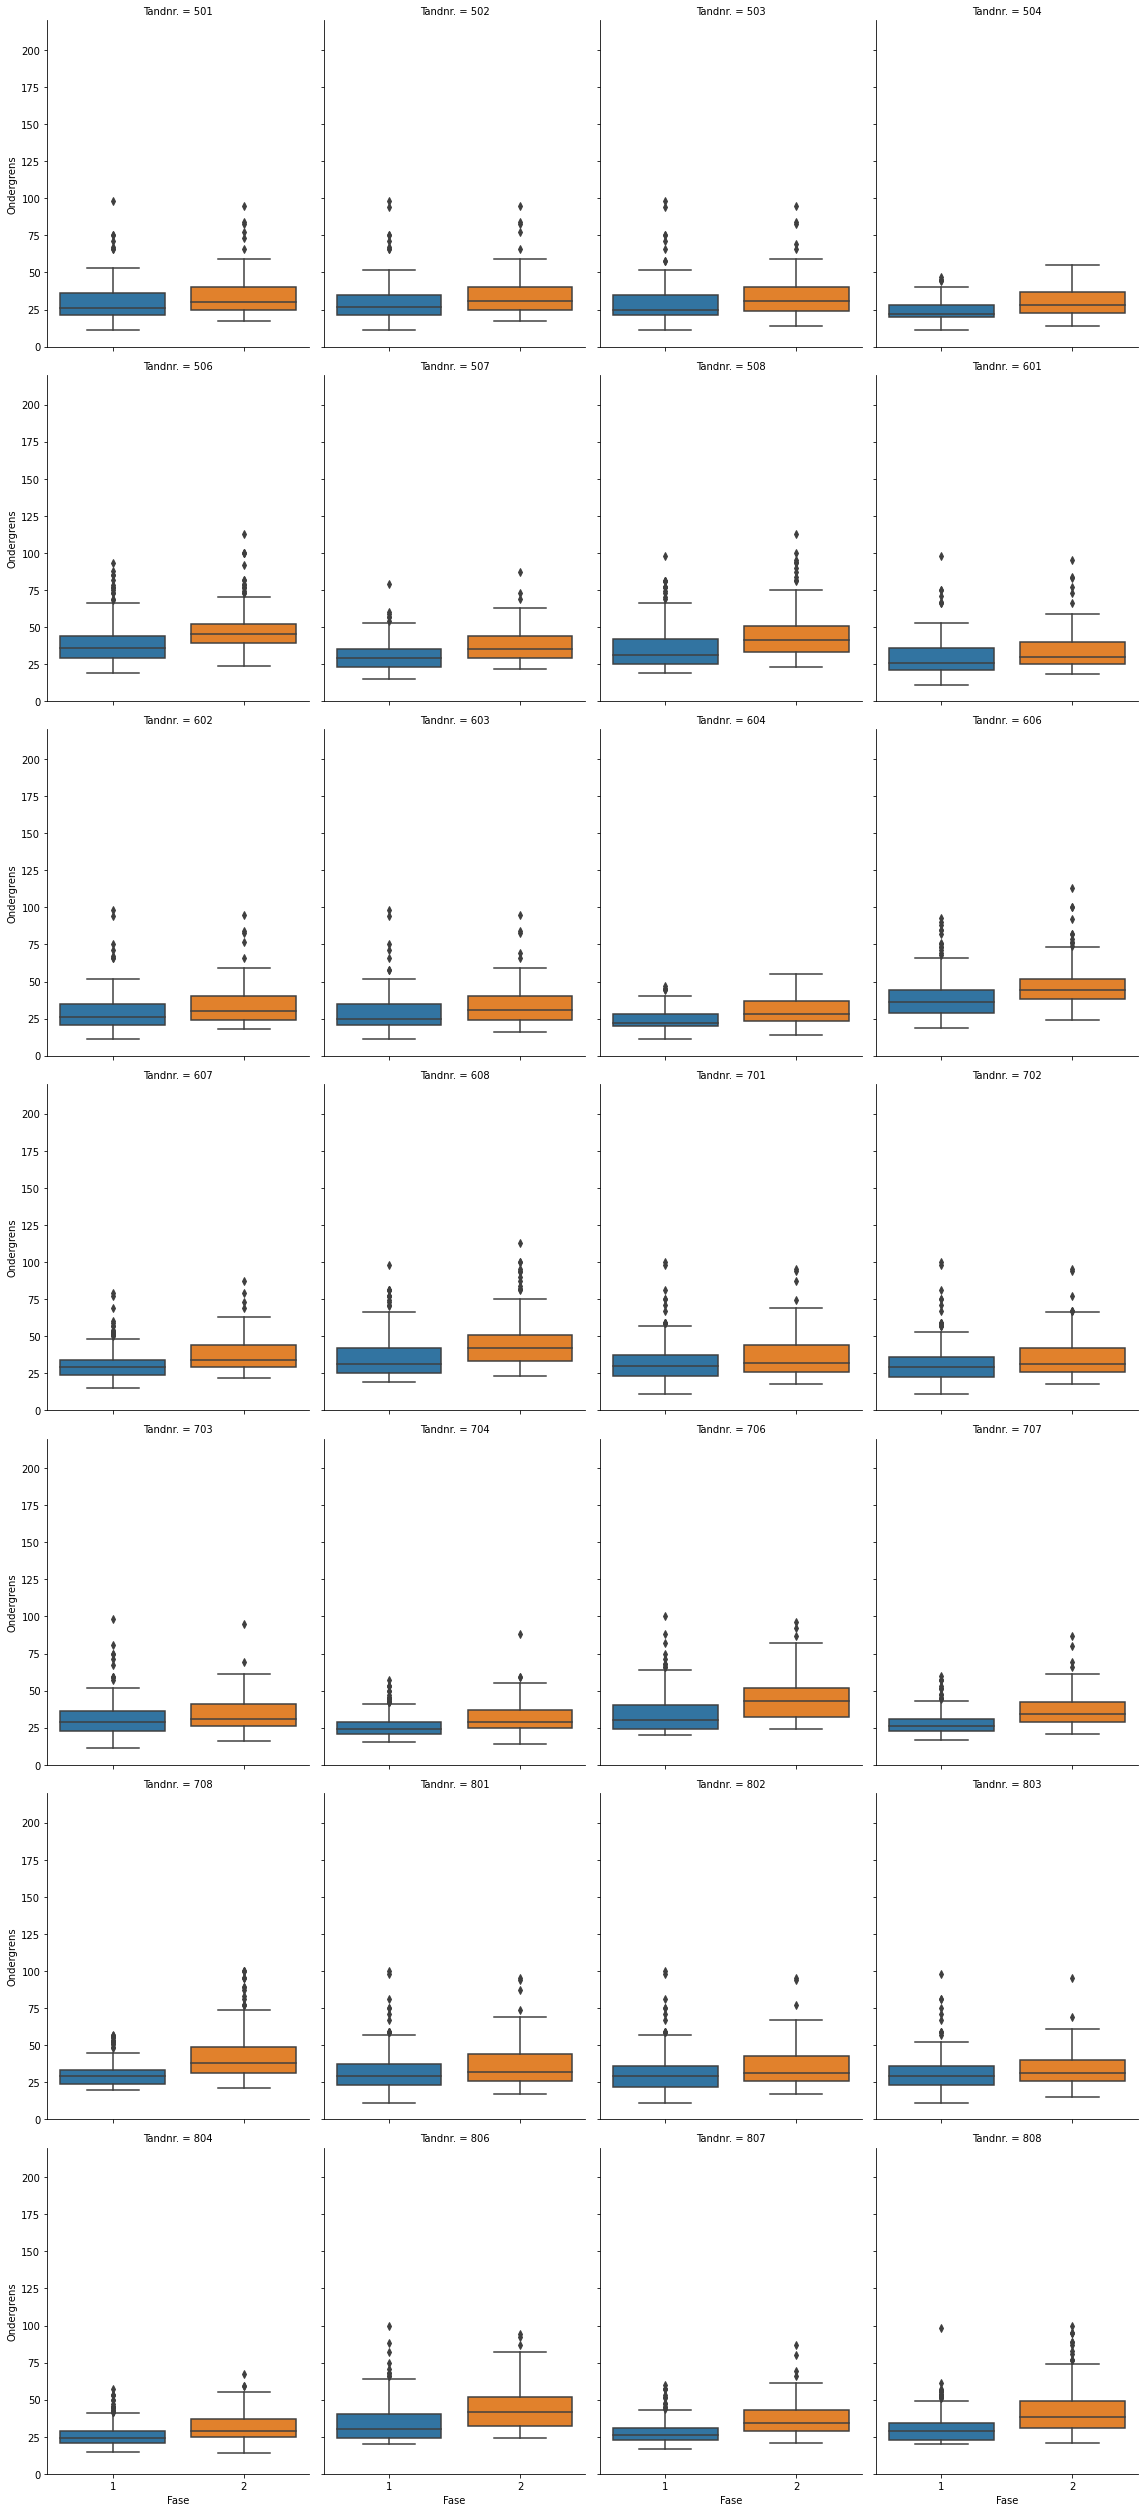

In [147]:
plot=sns.catplot(
    data=deciduous_teeth, x='DEVELOPM STAGE', y='LOWER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Ondergrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,220))
plot.set_titles("Tandnr. = {col_name}")

### UPPER

In [66]:
deciduous_teeth["UPPER"]=deciduous_teeth["UPPER"].replace('.', np.nan)
deciduous_teeth["UPPER"]=pd.to_numeric(deciduous_teeth["UPPER"])

TODO: per development stage bekijken, want min=11 en max=129 groot verschil

129 vrij afwijkend, want 75% = 49

In [67]:
deciduous_teeth["UPPER"].describe()

count    32672.000000
mean        40.838516
std         15.569709
min         11.000000
25%         29.000000
50%         39.000000
75%         49.000000
max        129.000000
Name: UPPER, dtype: float64

Ziet er vrij normaal uit --> ook hoge LOWER bij deze waarden

In [68]:
deciduous_teeth[deciduous_teeth["UPPER"]==129]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
538,608,MAX,L,8,2,NaN,129.0,0
538,508,MAX,R,8,2,NaN,129.0,0
538,708,MAND,L,8,2,77.0,129.0,1
538,808,MAND,R,8,2,77.0,129.0,1
539,608,MAX,L,8,2,NaN,129.0,0
539,508,MAX,R,8,2,NaN,129.0,0
539,708,MAND,L,8,2,77.0,129.0,1
539,808,MAND,R,8,2,77.0,129.0,1


                  count       mean        std   min   25%   50%   75%    max
DEVELOPM STAGE                                                              
1               11602.0  32.279176  12.136755  11.0  23.0  29.0  38.0  111.0
2               21070.0  45.551637  15.239483  18.0  35.0  42.0  54.0  129.0


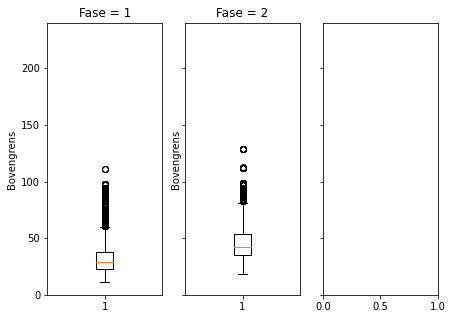

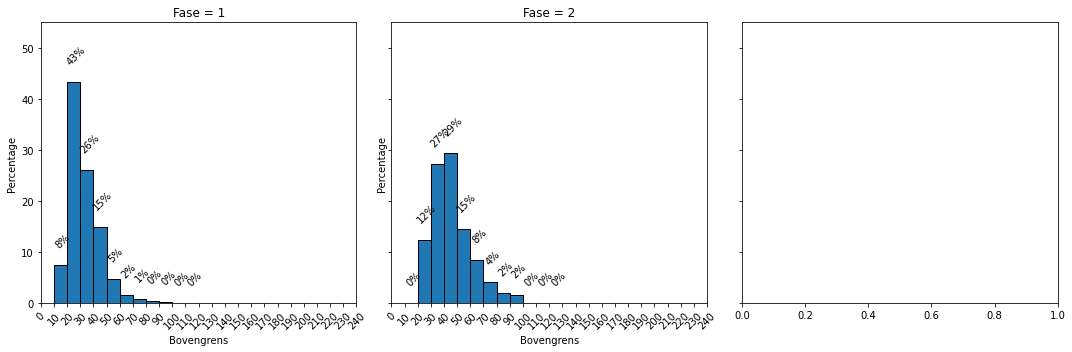

In [155]:
# group dataframe by quality values
dogs_developm_stage = deciduous_teeth[deciduous_teeth["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["UPPER"].describe())

# create a sub plot for each quality group
fig, axes = plt.subplots(ncols=3, 
                         figsize=[7,5],
                         sharey=True)

# loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    ax.boxplot(data['UPPER'])
    ax.set_title(f"Fase = {stage}")
    ax.set_ylabel('Bovengrens')
    ax.set_ylim(0, 240)




fig, axes = plt.subplots(ncols=3, 
                         figsize=[15, 5], sharey=True)
# Loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    bin_edges = range(int(min(data['UPPER'])) // 10 * 10, int(max(data['UPPER'])) // 10 * 10 + 20, 10)
    # Calculate the histogram with density=True for percentage
    counts, bins, patches = ax.hist(data['UPPER'], align='mid', edgecolor='black', bins=bin_edges, density=True)
    # Convert density to percentage
    bin_width = bins[1] - bins[0]  # Assuming bins are uniform
    counts_percent = counts * bin_width * 100  # Multiply by bin width and 100 to get percentage
    # Update the bars to represent percentages
    for patch, count in zip(patches, counts_percent):
        patch.set_height(count)
    # Annotate percentage values above the bars
    for patch in patches:
        height = patch.get_height()
        x_position = patch.get_x() + patch.get_width() / 2  # Position at the center of the bar
        ax.text(x_position+2, height + 3, f'{height:.0f}%', ha='center', va='bottom', fontsize=10,rotation=45)
    ax.set_title(f"Fase = {stage}")
    ax.set_xlabel('Bovengrens')
    ax.set_ylabel("Percentage")
    ax.set_xlim(0, 240)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(MultipleLocator(10))
plt.tight_layout()

PER TAND

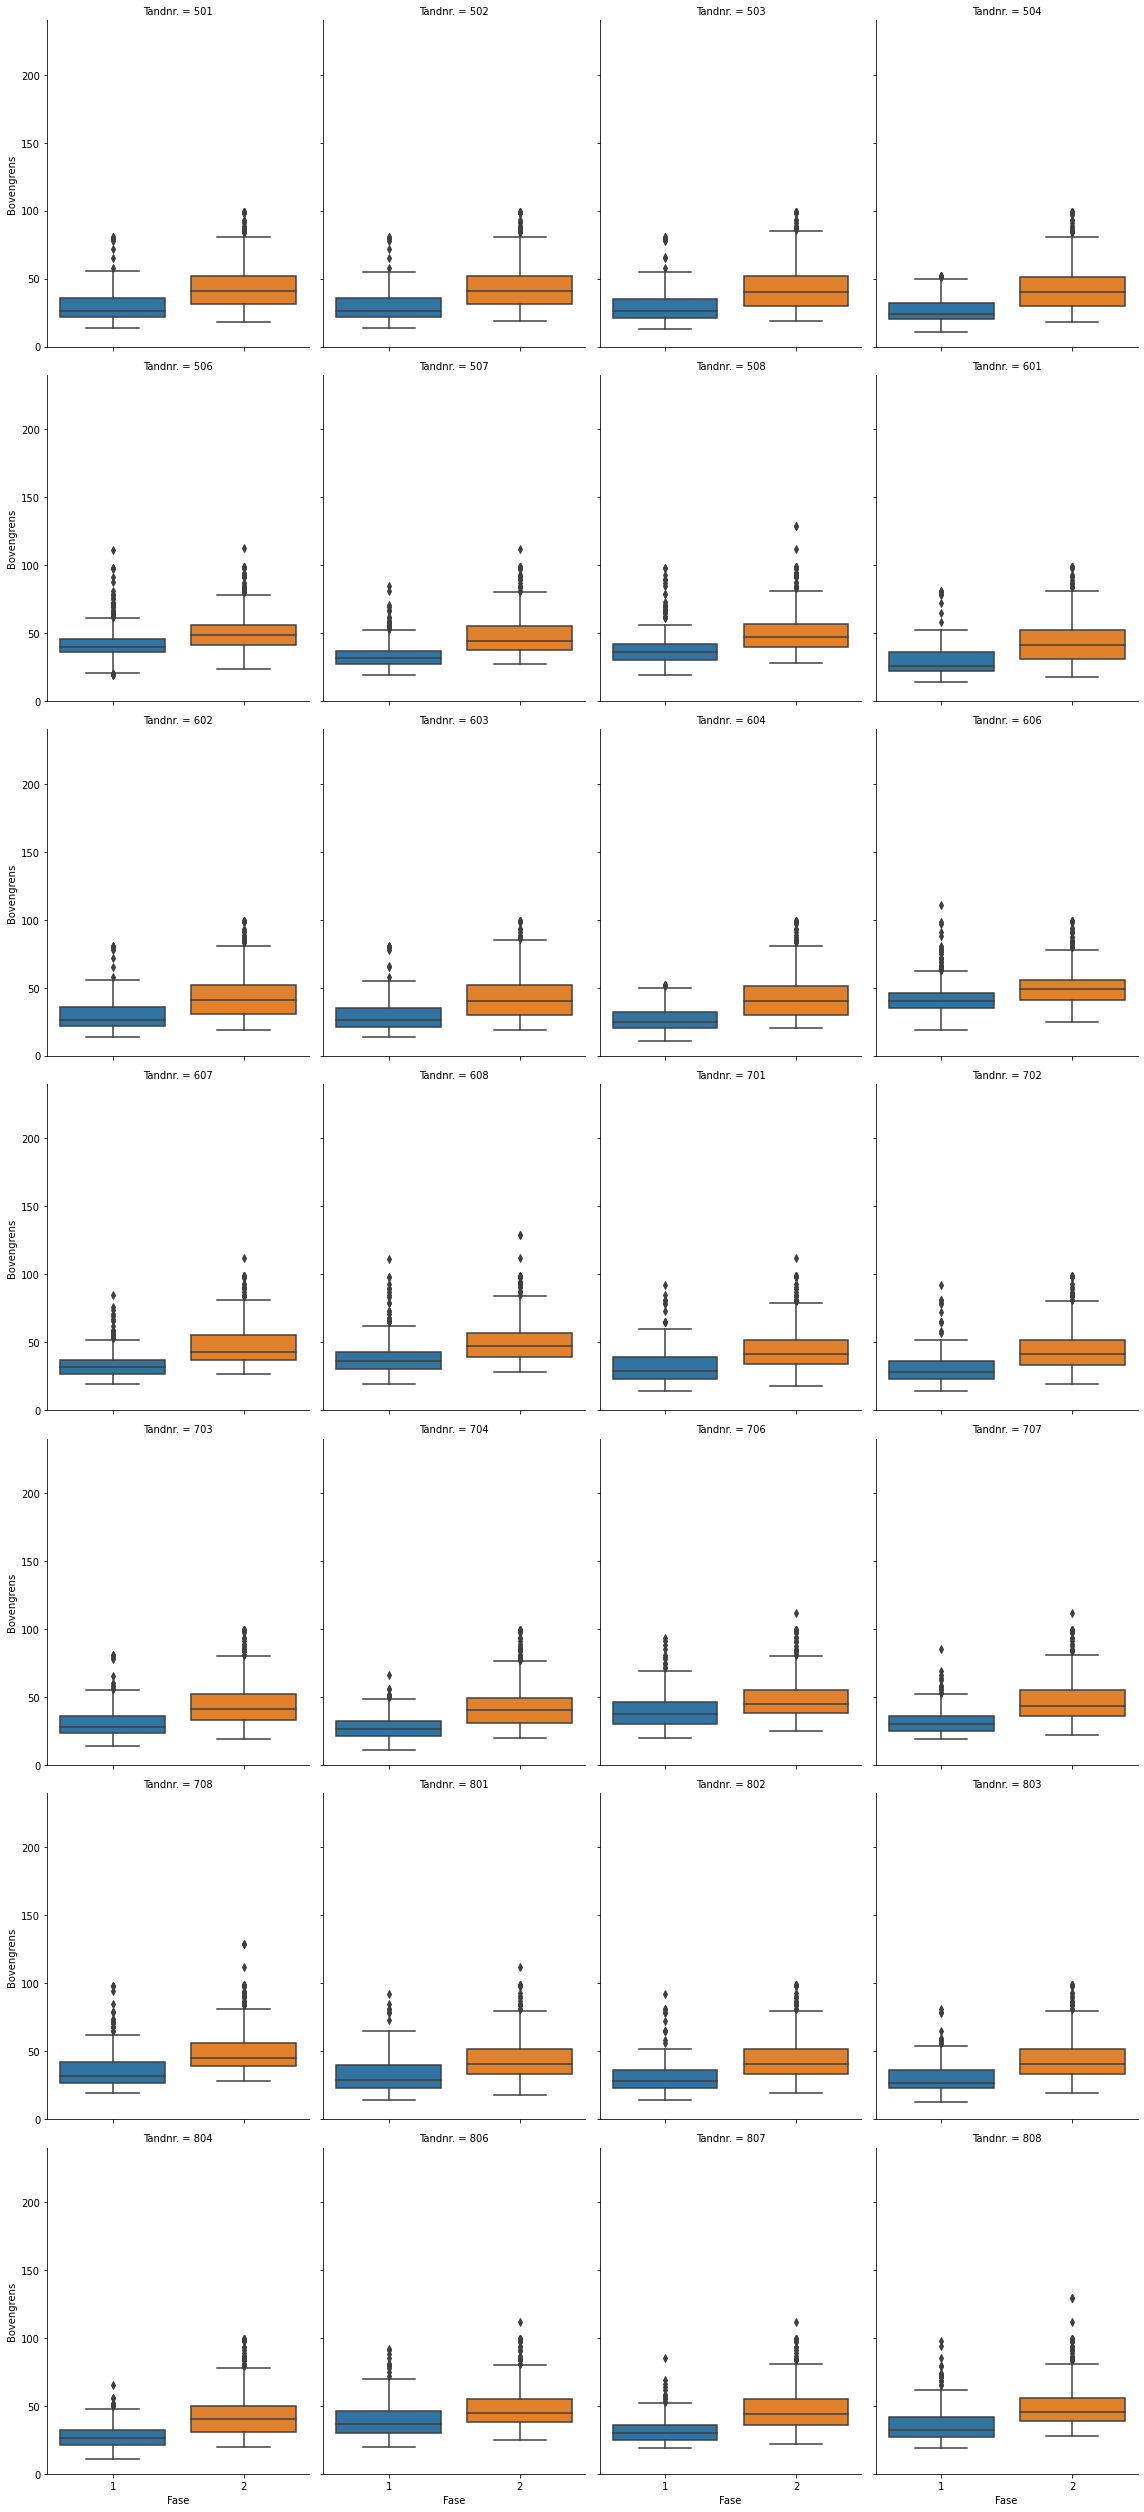

In [158]:
plot=sns.catplot(
    data=deciduous_teeth, x='DEVELOPM STAGE', y='UPPER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Bovengrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,240))
plot.set_titles("Tandnr. = {col_name}")

### SENS

SENS heeft vijf waarden:
- 0 = left
- 1 = interval
- 2 = right
- 3 = right of non-responder
- . = left?

In [69]:
deciduous_teeth["SENS"].unique()

array(['.', 0, 3, 1, 2], dtype=object)

- Meest left en .
- Right en non-responder minst

In [70]:
deciduous_teeth["SENS"].value_counts()

0    20181
.    16478
1    12491
2     6583
3      323
Name: SENS, dtype: int64

Wat als bij interval linker & rechter grens gelijk? --> nieuwe waarde = gn censoring

Komt 2444 vd 12496 keer voor

In [71]:
deciduous_teeth[((deciduous_teeth["LOWER"]==deciduous_teeth["UPPER"]) & (deciduous_teeth["SENS"]!='.'))]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
6,601,MAX,L,1,1,25.0,25.0,1
6,601,MAX,L,1,2,28.0,28.0,1
6,501,MAX,R,1,1,25.0,25.0,1
6,501,MAX,R,1,2,28.0,28.0,1
6,602,MAX,L,2,1,25.0,25.0,1
...,...,...,...,...,...,...,...,...
985,806,MAND,R,6,2,60.0,60.0,1
985,707,MAND,L,7,2,60.0,60.0,1
985,807,MAND,R,7,2,60.0,60.0,1


Nieuwe waarden def:
- 0 = gn censoring
- 1 = geen info
- 2 = left
- 3 = interval
- 4 = right
- 5 = right of non-responder

In [ ]:
deciduous_teeth["SENS"]=deciduous_teeth["SENS"].replace(3, 5)
deciduous_teeth["SENS"]=deciduous_teeth["SENS"].replace(2, 4)
deciduous_teeth["SENS"]=deciduous_teeth["SENS"].replace(1, 3)
deciduous_teeth["SENS"]=deciduous_teeth["SENS"].replace(0, 2)
deciduous_teeth.loc[((deciduous_teeth["LOWER"]==deciduous_teeth["UPPER"]) & (deciduous_teeth["SENS"]!='.'), "SENS")] = 0
deciduous_teeth["SENS"]=deciduous_teeth["SENS"].replace('.', 1)


Opmerkelijk veel left censoring

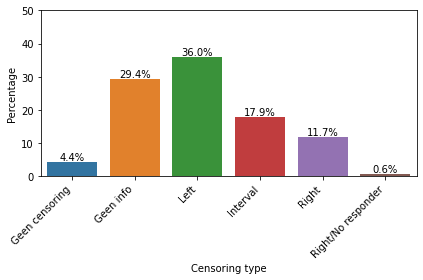

In [74]:
percentage = deciduous_teeth["SENS"].value_counts(normalize=True) * 100

plot = sns.barplot(x=percentage.index, y=percentage.values)
plot.set_xticklabels(
    ['Geen censoring', 'Geen info', 'Left', 'Interval', 'Right', 'Right/No responder'],
    rotation=45,  
    ha='right'    
)
plot.set_xlabel('Censoring type')
plot.set_ylim(0,50)
plot.set_ylabel('Percentage')
# Add percentage labels above the bars
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()

#### 0: geen censoring (LOWER==UPPER)

226 honden

In [75]:
df_no_censoring = deciduous_teeth[deciduous_teeth["SENS"]==0]
df_no_censoring.index.value_counts()
df_no_censoring[df_no_censoring['LOWER'].isna()]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,


In [76]:
df_no_censoring[df_no_censoring['SENS']==0].groupby('DEVELOPM STAGE')['TOOTH NUMBER'].value_counts()

DEVELOPM STAGE  TOOTH NUMBER
1               504             79
                501             74
                502             74
                602             74
                601             73
                604             71
                503             63
                603             62
                804             56
                704             53
                703             50
                803             47
                702             44
                802             43
                701             40
                801             40
                606             35
                807             35
                506             34
                707             34
                507             31
                607             30
                706             25
                608             24
                806             24
                508             23
                808             23
                708       

In [77]:
# group dataframe by quality values
dogs_developm_stage = df_no_censoring[df_no_censoring["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["UPPER"].describe())

                 count       mean        std   min   25%   50%   75%   max
DEVELOPM STAGE                                                            
1               1283.0  23.171473   6.120238  11.0  20.0  22.0  25.0  57.0
2               1161.0  34.267011  11.916492  18.0  26.0  30.0  45.0  94.0


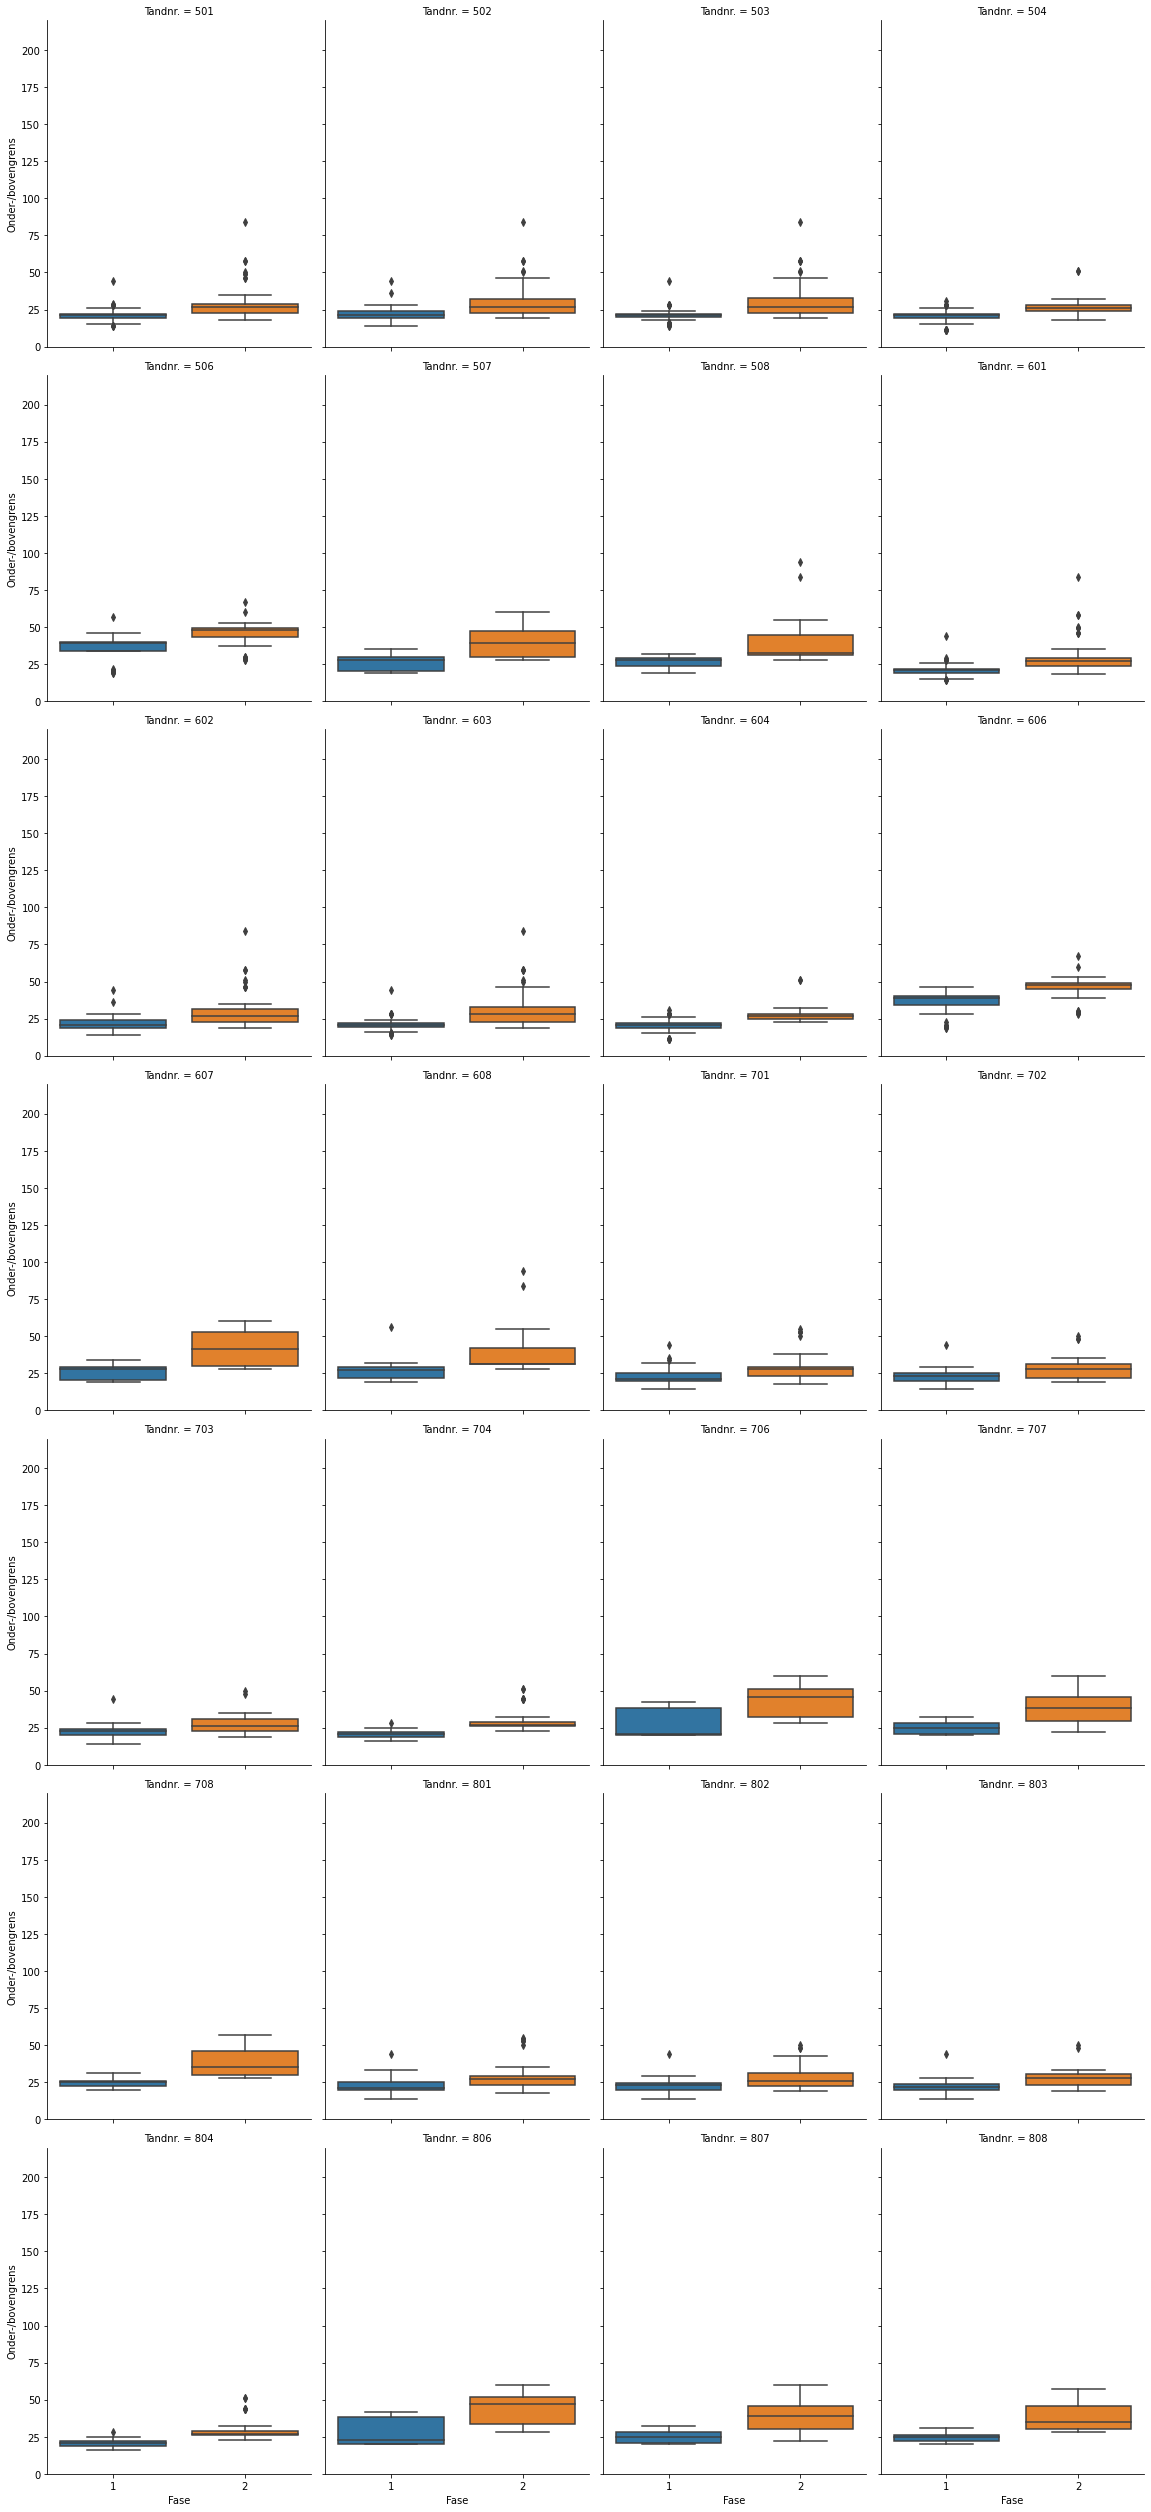

In [193]:
plot=sns.catplot(
    data=df_no_censoring, x='DEVELOPM STAGE', y='LOWER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Onder-/bovengrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,220))
plot.set_titles("Tandnr. = {col_name}")

Van 1 hond

<AxesSubplot:xlabel='LOWER', ylabel='UPPER'>

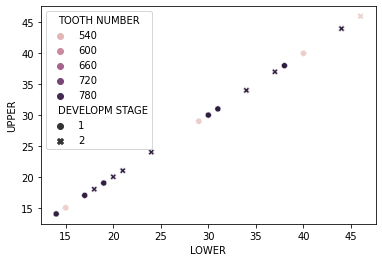

In [195]:
df_dog_11 = deciduous_teeth[deciduous_teeth.index==11]
sns.scatterplot(df_dog_11, x="LOWER", y="UPPER", style="DEVELOPM STAGE", hue="TOOTH NUMBER")

#### 2: left censoring

enkel eindpunt plotten

tellen hoeveel lower en upper nan

In [78]:
df_left_censoring = deciduous_teeth[(deciduous_teeth["SENS"]==2)&(deciduous_teeth["UPPER"].notna())]
df_left_censoring.index.value_counts()

446    56
445    56
449    56
448    56
447    56
       ..
277     1
254     1
588     1
486     1
273     1
Name: DOG, Length: 925, dtype: int64

In [79]:
dogs_developm_stage = df_left_censoring[df_left_censoring["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["UPPER"].describe())

                  count       mean        std   min   25%   50%   75%    max
DEVELOPM STAGE                                                              
1                6617.0  31.100196  12.179523  11.0  22.0  28.0  36.0  111.0
2               13564.0  47.984370  16.389347  20.0  36.0  44.0  58.0  129.0


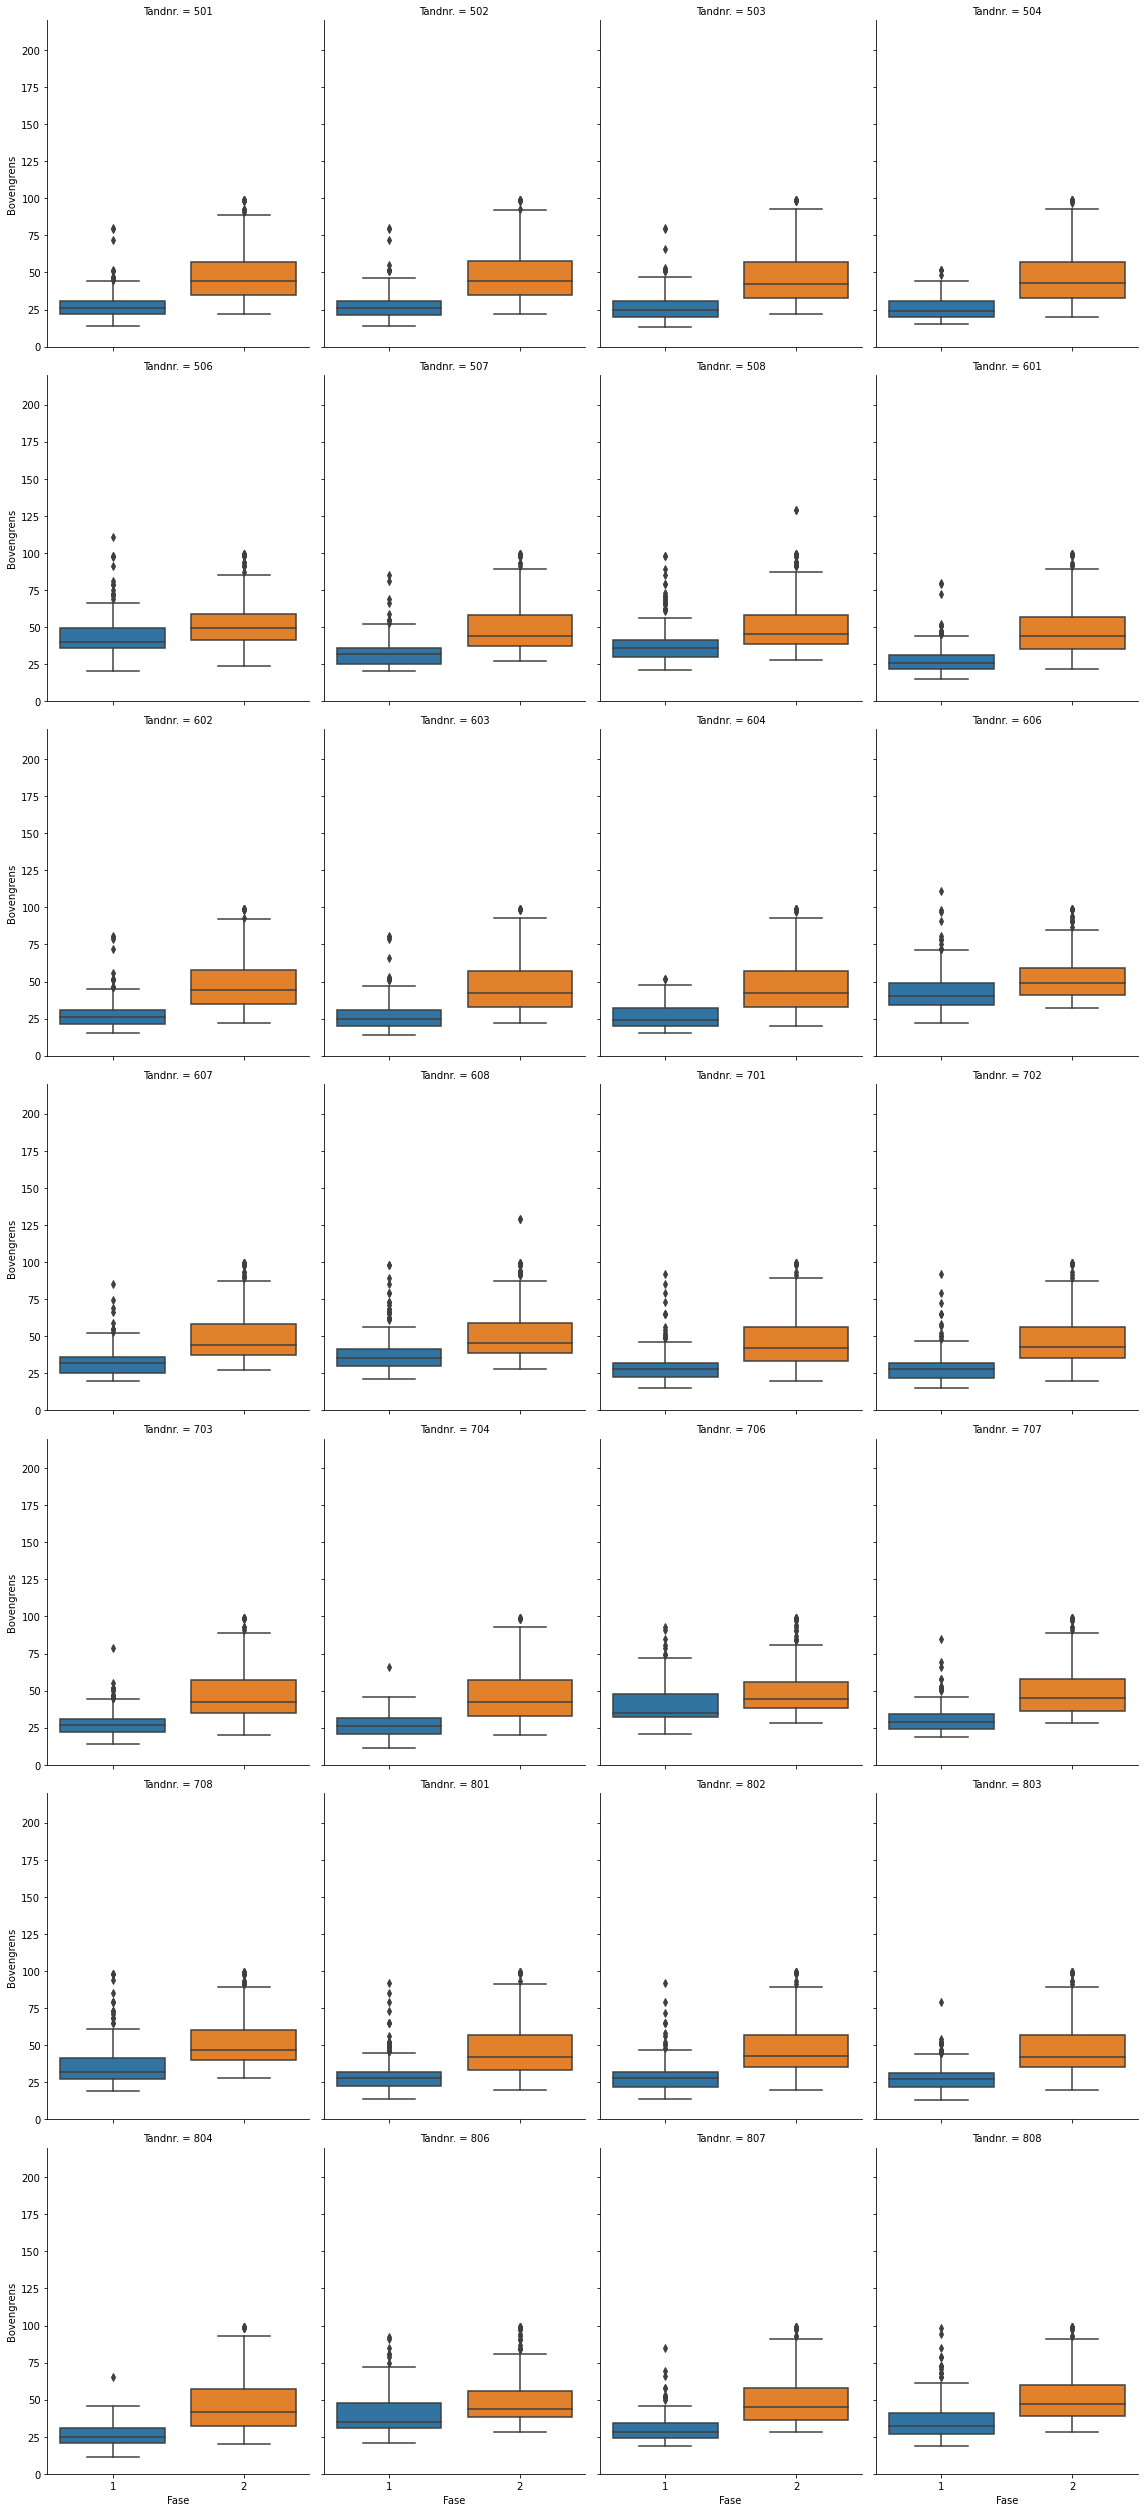

In [217]:
plot=sns.catplot(
    data=df_left_censoring, x='DEVELOPM STAGE', y='UPPER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Bovengrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,220))
plot.set_titles("Tandnr. = {col_name}")

#### 3: inteval censoring

556 honden

In [80]:
df_interval_censoring = deciduous_teeth[deciduous_teeth["SENS"]==3]
df_interval_censoring.index.value_counts()

132    56
694    56
693    56
296    54
321    53
       ..
174     1
959     1
588     1
102     1
720     1
Name: DOG, Length: 556, dtype: int64

In [82]:
dogs_developm_stage = df_interval_censoring[df_interval_censoring["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["LOWER"].describe())
print(dogs_developm_stage["UPPER"].describe())

                 count       mean        std   min   25%   50%   75%    max
DEVELOPM STAGE                                                             
1               3702.0  31.047812   9.852993  15.0  24.0  29.0  36.0   98.0
2               6345.0  34.395272  10.058942  19.0  26.0  32.0  40.0  100.0
                 count       mean        std   min   25%   50%   75%    max
DEVELOPM STAGE                                                             
1               3702.0  37.542950  11.163091  19.0  28.0  36.0  44.0  111.0
2               6345.0  42.415918  11.192355  20.0  35.0  42.0  49.0  129.0


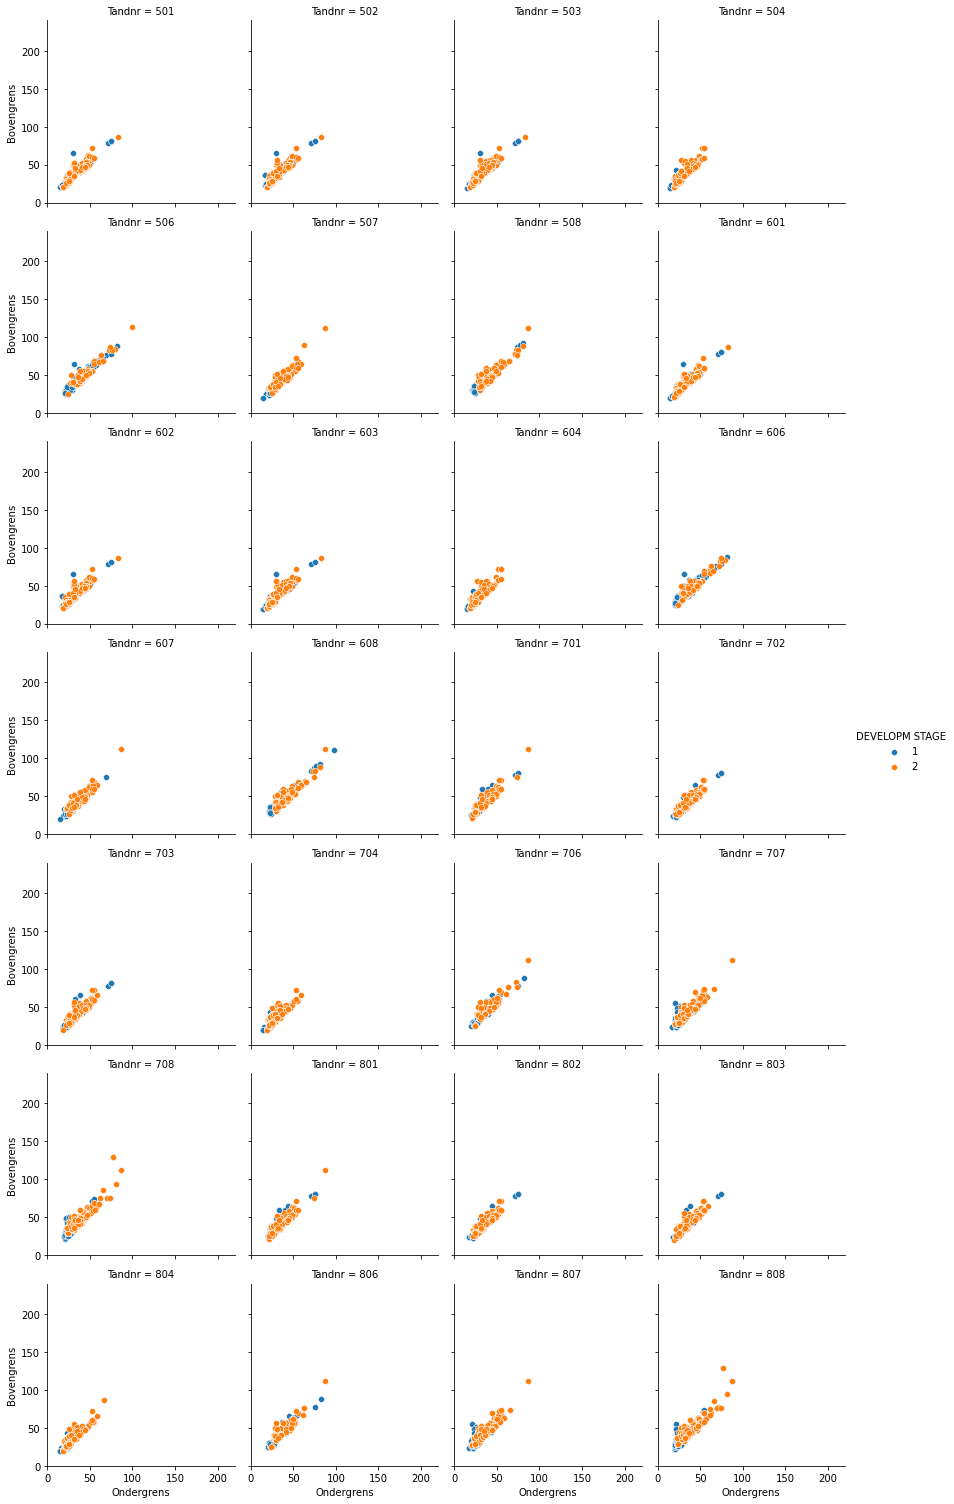

In [242]:
g = sns.FacetGrid(df_interval_censoring, col="TOOTH NUMBER", hue="DEVELOPM STAGE", col_wrap=4)
g.map(sns.scatterplot, "LOWER", "UPPER")
g.set(ylim=(0,240), xlim=(0,220))
g.add_legend()
g.set_ylabels('Bovengrens')
g.set_xlabels('Ondergrens')
g.set_titles('Tandnr = {col_name}')

correlated = logisch

<Figure size 576x432 with 0 Axes>

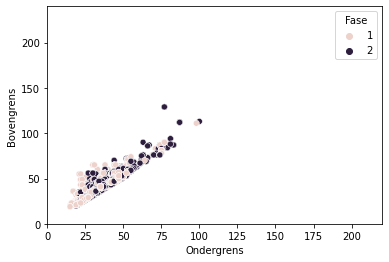

<Figure size 576x432 with 0 Axes>

In [84]:
plot=sns.scatterplot(data=df_interval_censoring, x="LOWER", y="UPPER", hue="DEVELOPM STAGE")
plot.set(ylim=(0,240))
plot.set(xlim=(0,220))
plot.set_xlabel('Ondergrens')
plot.set_ylabel('Bovengrens')
plot.legend(title='Fase')
plt.figure(figsize=(8, 6))

Paar punten liggen onder rechte lijn --> lower > upper? (moeten deze waarden dan gewisseld worden?)

In [85]:
df_interval_censoring[df_interval_censoring["LOWER"]>df_interval_censoring["UPPER"]]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,


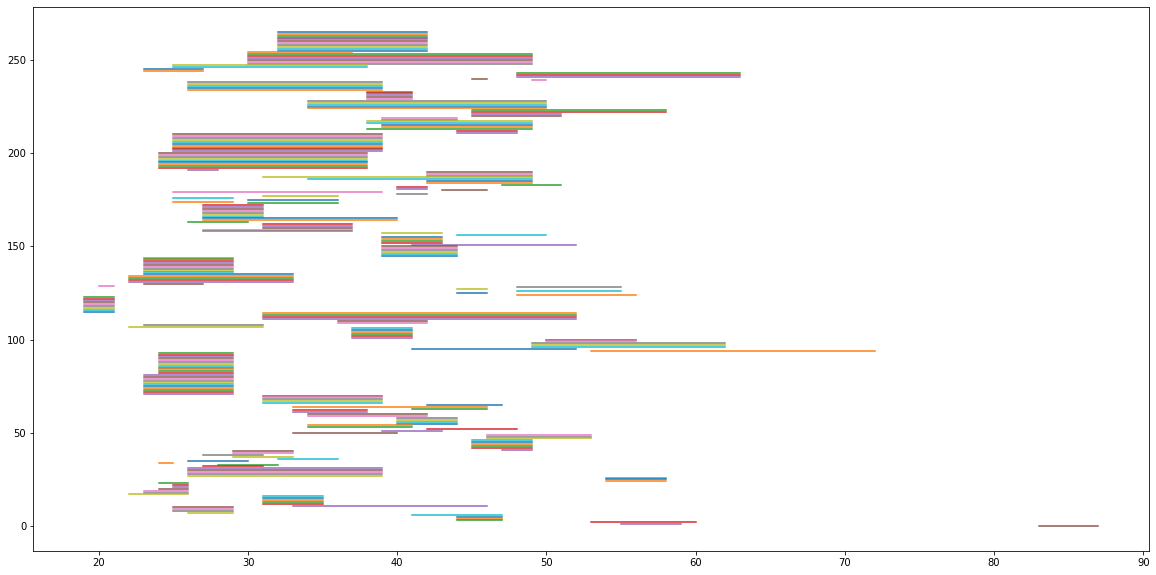

In [ ]:
#TODO:per tooth nr?
df_interval_censoring=df_interval_censoring[(df_interval_censoring["TOOTH NUMBER"]==601)&(df_interval_censoring["DEVELOPM STAGE"]==2)].reset_index()
plt.figure(figsize=(20,10))
plt.plot(np.vstack((df_interval_censoring["LOWER"], df_interval_censoring["UPPER"])),
         np.vstack((df_interval_censoring.index, df_interval_censoring.index))[:, ~df_interval_censoring.index])

#### 4: right censoring

enkel startpunt plotten

In [86]:
df_right_censoring = deciduous_teeth[(deciduous_teeth["SENS"]==4)&(deciduous_teeth["LOWER"].notna())&(deciduous_teeth["LOWER"]<323)]
df_right_censoring.index.value_counts()

512    28
209    28
513    28
511    28
510    28
       ..
273     1
622     1
428     1
970     1
19      1
Name: DOG, Length: 600, dtype: int64

In [87]:
dogs_developm_stage = df_right_censoring[df_right_censoring["LOWER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["LOWER"].describe())

                 count       mean        std   min   25%   50%   75%   max
DEVELOPM STAGE                                                            
1               3789.0  32.805226  11.766878  11.0  23.0  31.0  38.0  98.0
2               2793.0  39.225206  13.002222  14.0  29.0  38.0  49.0  93.0


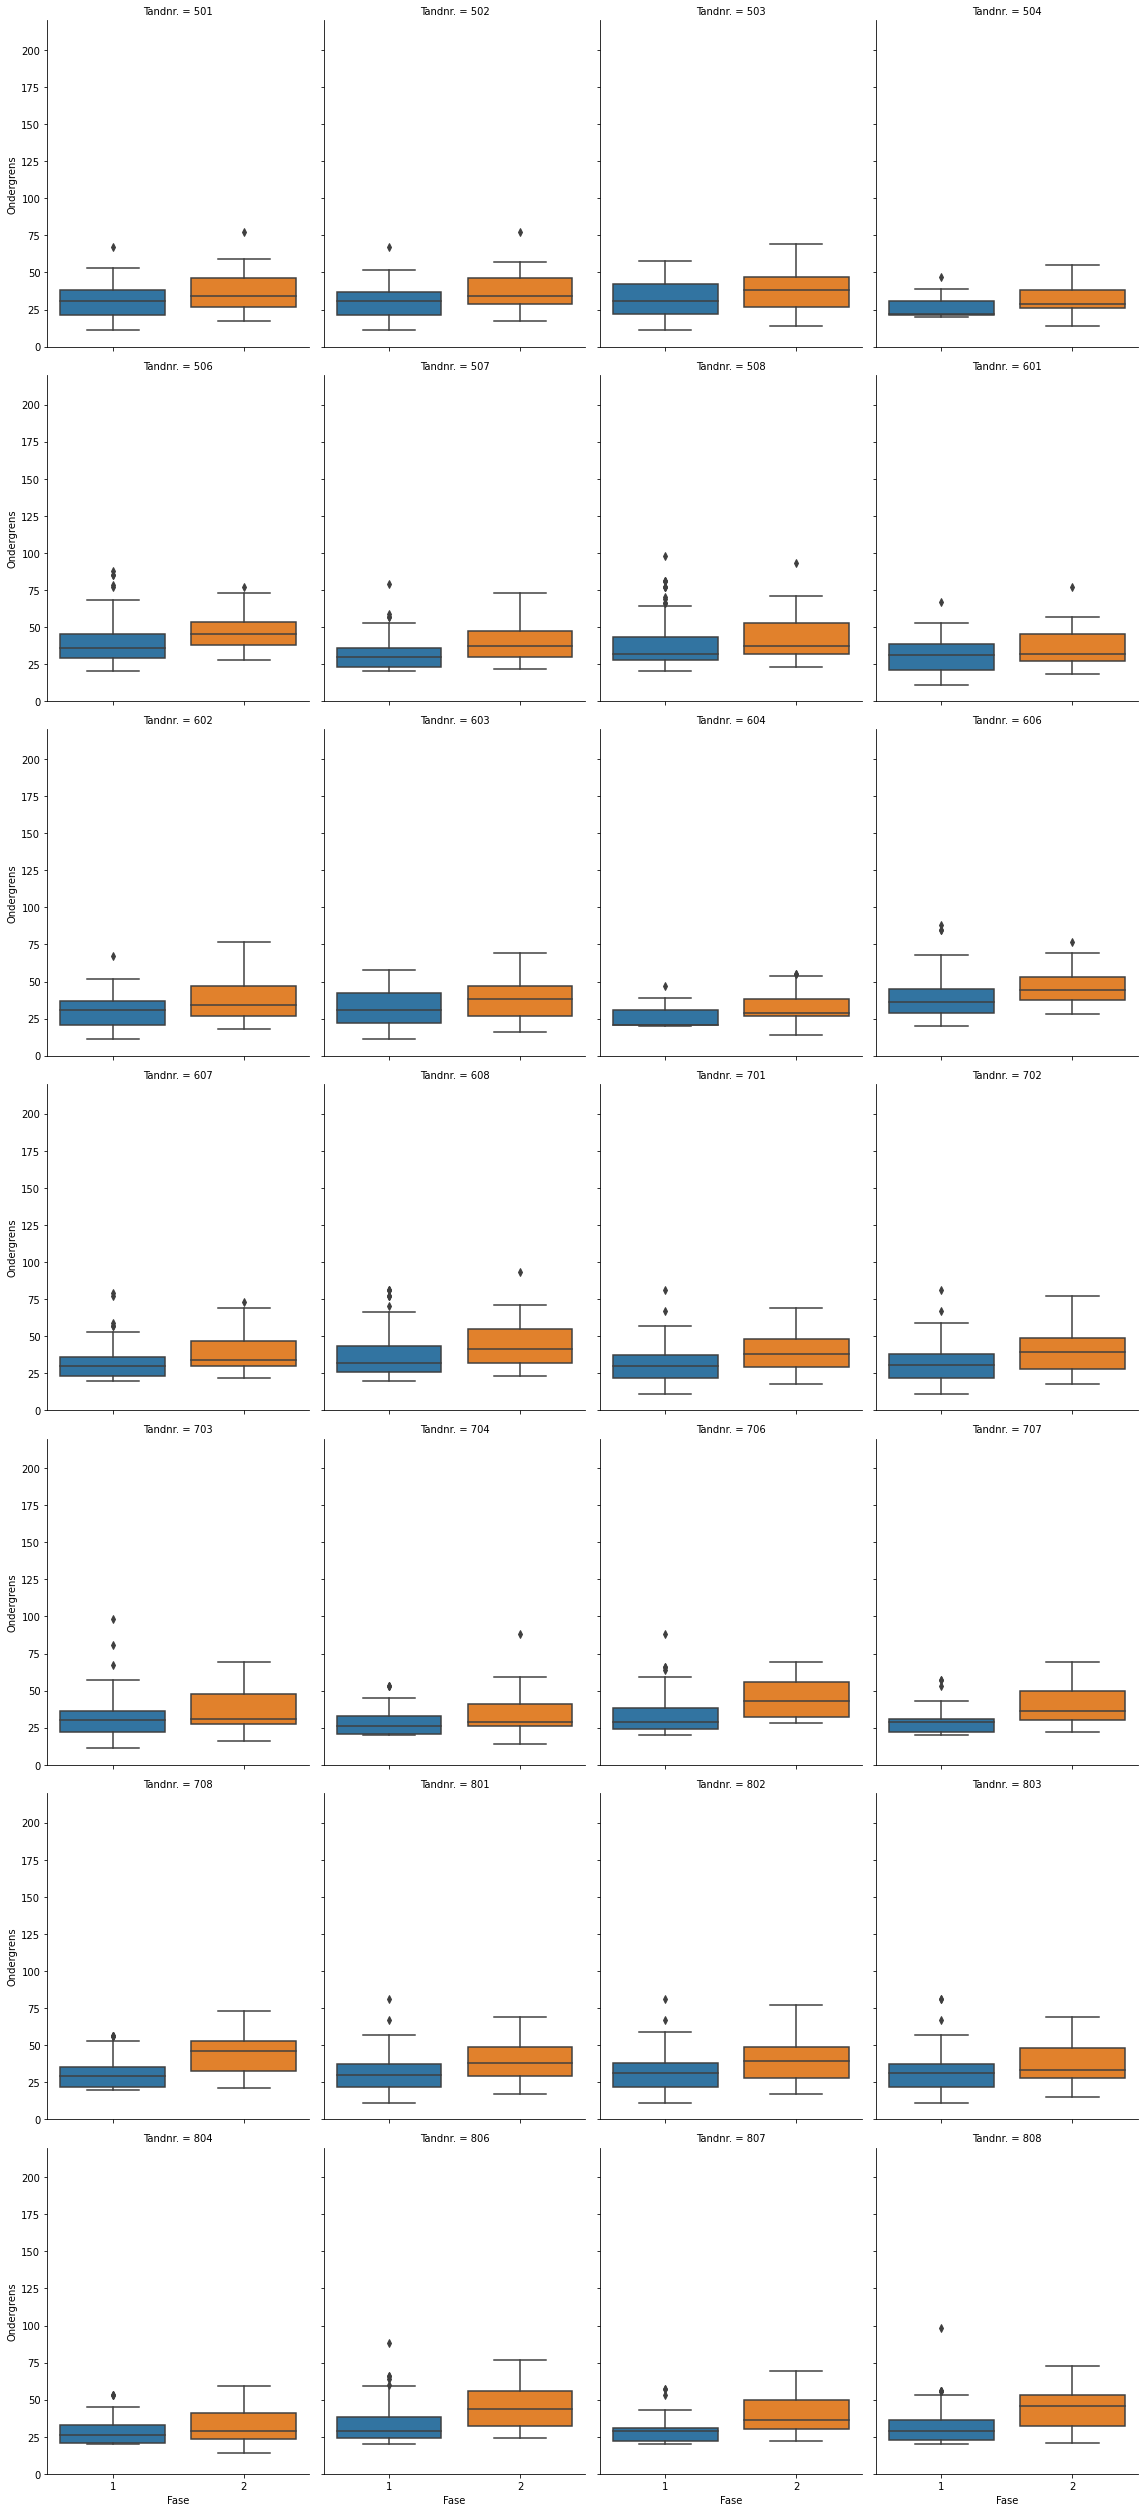

In [287]:
plot=sns.catplot(
    data=df_right_censoring, x='DEVELOPM STAGE', y='LOWER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Ondergrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,220))
plot.set_titles("Tandnr. = {col_name}")

#### 4

komt bij bepaalde tanden vaker voor

In [90]:
df_right_no_censoring = deciduous_teeth[deciduous_teeth["SENS"]==5]
df_right_no_censoring["TOOTH NUMBER"].value_counts()

508    27
608    27
708    26
808    24
606    24
506    23
806    19
706    18
701    17
801    17
501    10
802    10
702    10
601    10
602     9
502     9
803     8
603     8
703     7
503     7
607     4
507     3
807     2
707     2
704     1
804     1
Name: TOOTH NUMBER, dtype: int64

In [91]:
df_right_no_censoring.groupby("DEVELOPM STAGE")["LOWER"].describe()

,count,mean,std,min,25%,50%,75%,max
DEVELOPM STAGE,,,,,,,,
1,123.0,68.390244,14.948893,56.0,59.0,60.0,73.0,100.0
2,200.0,72.705000,15.964722,50.0,61.0,66.0,89.0,113.0


correlation matrix

<AxesSubplot:>

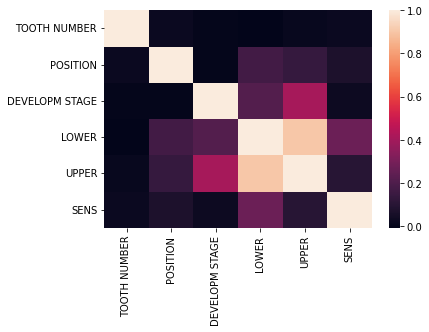

In [ ]:
corr = deciduous_teeth.corr()
sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

## Wegschrijven dataframes

In [92]:
with pd.ExcelWriter('../data/deciduous_EDA_clean.xlsx') as writer:
   deciduous_dogs.to_excel(writer, sheet_name='dogs')
   deciduous_teeth.to_excel(writer, sheet_name='teeth')

## Dogs & Teeth

In [ ]:
#juiste join?
df = pd.merge(deciduous_teeth, deciduous_dogs, on='DOG')

In [ ]:
df.head(56)

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS,SEX,BREED,LITTER,BREED SIZE,SKULL TYPE,BREED CLADE,RELIABILITY (1/2)
DOG,,,,,,,,,,,,,,,
1,601,MAX,L,1,1,NaN,NaN,1,F,Akita Inu,Single,Large,Meso,A,2
1,601,MAX,L,1,2,NaN,63.0,1,F,Akita Inu,Single,Large,Meso,A,2
1,501,MAX,R,1,1,NaN,NaN,1,F,Akita Inu,Single,Large,Meso,A,2
1,501,MAX,R,1,2,NaN,63.0,1,F,Akita Inu,Single,Large,Meso,A,2
1,602,MAX,L,2,1,NaN,NaN,1,F,Akita Inu,Single,Large,Meso,A,2
1,602,MAX,L,2,2,NaN,63.0,1,F,Akita Inu,Single,Large,Meso,A,2
1,502,MAX,R,2,1,NaN,NaN,1,F,Akita Inu,Single,Large,Meso,A,2
1,502,MAX,R,2,2,NaN,63.0,1,F,Akita Inu,Single,Large,Meso,A,2
1,603,MAX,L,3,1,NaN,NaN,1,F,Akita Inu,Single,Large,Meso,A,2


# Permanent

In [31]:
permanent_dogs = pd.read_excel('../data/permanent_dentition_tables_statistics_final_2022.xlsx', index_col=0, sheet_name='Dog characteristics')
permanent_teeth = pd.read_excel('../data/permanent_dentition_tables_statistics_final_2022.xlsx', index_col=0, sheet_name='Data')

## Dogs

### Overzicht volledige dataset

- terug een unnamed kolom (info nakomertje & kruising bij enkele honden)
- litter bevat .
- extra kolom study

In [187]:
permanent_dogs.head()

,SEX,BREED,LITTER,BREED SIZE,SKULL TYPE,BREED CLADE,RELIABILITY (1/2),STUDY,Unnamed: 9
DOG,,,,,,,,,
1,F,Akita Inu,.,Large,Meso,A,2,SINGLE,NaN
2,F,Akita Inu,.,Large,Meso,A,2,SINGLE,NaN
3,M,Akita Inu,.,Large,Meso,A,2,SINGLE,NaN
4,F,Akita Inu,.,Large,Meso,A,2,SINGLE,NaN
5,M,American Akita,.,Large,Meso,A,1,LONG,NaN


In [32]:
permanent_dogs.drop('Unnamed: 9', axis=1, inplace=True)

440 pups werden opgevolgd in de studie

In [189]:
permanent_dogs.shape

(440, 8)

BREED CLADE heeft 2 null waarden

In [190]:
permanent_dogs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 440 entries, 1 to 440
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SEX                440 non-null    object
 1   BREED              440 non-null    object
 2   LITTER             440 non-null    object
 3   BREED SIZE         440 non-null    object
 4   SKULL TYPE         440 non-null    object
 5   BREED CLADE        438 non-null    object
 6   RELIABILITY (1/2)  440 non-null    int64 
 7   STUDY              440 non-null    object
dtypes: int64(1), object(7)
memory usage: 30.9+ KB


Opvallend bij describe:
- Veel meer rassen dan bij deciduous
- Meer BREED SIZE (waarvan Large nu meest voorkomend)
- Meer SKULL TYPE
- Meer BREED CLADE

In [191]:
permanent_dogs.describe(include=["object"])

,SEX,BREED,LITTER,BREED SIZE,SKULL TYPE,BREED CLADE,STUDY
count,440,440,440,440,440,438,440
unique,3,84,108,6,7,23,3
top,F,Golden Retriever,.,Large,Meso,Q,LONG
freq,244,29,329,139,258,54,269


### SEX

Opvallend meer F dan M

['F' 'M' '?']


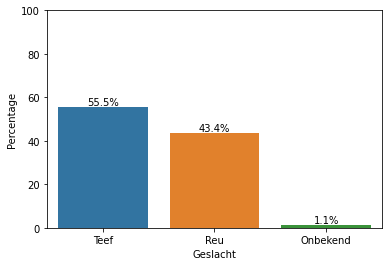

F    244
M    191
X      5
Name: SEX, dtype: int64

In [33]:
print(permanent_dogs["SEX"].unique())

permanent_dogs['SEX']=permanent_dogs['SEX'].replace('?', 'X')

# Normalize the counts to percentages
total_count = len(permanent_dogs)
percentage = permanent_dogs['SEX'].value_counts(normalize=True) * 100

# Create a percentage-based bar plot
plot = sns.barplot(x=percentage.index, y=percentage.values)
plot.set_xlabel('Geslacht')
plot.set_ylabel('Percentage')
plot.set_xticklabels(['Teef', 'Reu', 'Onbekend'])
plot.set(ylim=(0, 100))  # Percentage axis ranges from 0 to 100

# Add percentage labels above the bars
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

permanent_dogs["SEX"].value_counts()

### BREED

Dachshund & Dachshund met spatie --> samennemen

In [34]:
print(permanent_dogs["BREED"].unique())

permanent_dogs['BREED']=permanent_dogs['BREED'].replace('Dachshund ', 'Dachshund')

print(permanent_dogs['BREED'].value_counts()[:10])

# Create the treemap
fig = px.treemap(data_frame=permanent_dogs, path=['BREED'], width=1200, height=700)
# Calculate the percentage dynamically for each segment
fig.update_traces(
    texttemplate="%{label}<br>%{value} (%{percentEntry:.2%})",
    textinfo="label+value"
)
# Adjust layout and font size
fig.update_layout(margin=dict(t=0, l=0, r=0, b=25))
fig.update_traces(textfont_size=16)
# Show the plot
fig.show()

['Akita Inu' 'American Akita' 'American Staffordshire Terrier'
 'Australian Cattle Dog' 'Australian Shepherd' 'Beagle' 'Bearded Collie'
 'Bernese Mountain dog' 'Bichon Frise' 'Bobtail' 'Boerboel'
 'Border Collie' 'Bouvier' 'Bullmastiff' 'Bull Terrier MINIATURE'
 'Bull Terrier STANDARD' 'Cane Corso' 'Caucasian Shepherd Dog'
 'Cavalier King Charles Spaniel' 'Chihuahua' 'Chinese Crested Dog'
 'Dachshund' 'Dachshund ' 'Dalmatian' 'Decoy Dog' 'Drentse Patrijs'
 'Dutch Shepherd' 'English Bulldog' 'English Cocker Spaniel'
 'English Springer Spaniel' 'Epagneul Français' 'Finnish Lapphund'
 'Fox Terrier' 'French Bulldog' 'German Shepherd '
 'German Shorthaired Pointer' 'Golden Retriever' 'Gordon Setter'
 'Great Dane' 'Greyhound' 'Griffon Korthals' 'Havaneze' 'Irish Setter'
 'Irish Soft coated wheaten terrier' 'Jack Russell Terrier' 'Korean Jindo'
 'Kuvasz' 'Labradoodle' 'Labrador Retriever' 'Lhasa Apso' 'Malinois'
 'Maltese' 'Newfoundland' 'Nova Scottia Duck Tolling Retriever'
 'Pomeranian ' 'P

### LITTER

LITTER wordt hier anders gedef: 
- . = Single
- Beagle 1-3 = 3de pup van eerste litter Beagle --> -... wegnemen zodat het overeenkomt met deciduous
- Niet veel pups zijn afkomstig van een LITTER
- Sommige LITTERs hebben maar 1 pup --> Single?

In [35]:
print(permanent_dogs["LITTER"].unique())

permanent_dogs['LITTER']=permanent_dogs['LITTER'].replace('.', 'Single')
permanent_dogs['LITTER']=permanent_dogs['LITTER'].map(lambda d: d.split('-', 1)[0].strip())

s = permanent_dogs['LITTER'].value_counts()
permanent_dogs.loc[permanent_dogs['LITTER'].isin(s[s==1].index), 'LITTER'] = 'Single'

print(permanent_dogs['LITTER'].value_counts()[:10])

litter_counts = permanent_dogs.groupby(['BREED', 'LITTER']).size().reset_index(name='count')
breed_totals = litter_counts.groupby('BREED')['count'].sum().reset_index(name='total')
litter_counts = litter_counts.merge(breed_totals, on='BREED')
litter_counts['percentage'] = (litter_counts['count'] / litter_counts['total']) * 100

fig = px.treemap(litter_counts, path=['BREED', 'LITTER'], values='count', width=1200, height=700, hover_data=['percentage'])
fig.data[0].textinfo = 'label+value+percent entry'
fig.data[0].texttemplate = '%{label}<br>%{value}<br>%{customdata[0]:.1f}%'
fig.update_traces(textfont_size=16)
fig.update_layout(margin=dict(t=0, l=0, r=0, b=25))
fig.show()

['.' 'Beagle 1-3' 'Beagle 1-6' 'BS 1 - pup 5' 'BS 1 - pup 1'
 'BS 2- pup 12' 'BS 4-pup 1' 'BS 5- pup 5' 'BS 7- pup 1' 'BS 7- pup 6'
 'BS 8 - 6 of 7' 'BS 9- pup 5' 'BS 9- pup 7?' 'BS 9- pup 8' 'BS 2 -pup 14'
 'BS 8-pup 5' 'MIN BULL T 1-5' 'MIN BULL T 1-4' 'CKCh1-…..' 'CKCh3-2'
 'Drent 2-2' 'Drent 2-6' 'Drent 2-1' 'Drent 2-8' 'Drent 2-5' 'Drent 2-9'
 'Drent 2-4' 'Drent 1-2' 'Drent 1-6' 'Engelse Bulldog 1-4'
 'Engelse Bulldog 1-7' 'Cocker Sp 2-6' 'ESS 4-pup 4' 'ESS 4-pup 6'
 'ESS 4-pup 7' 'ESS 4-pup 5' 'ESS 4-pup 1' 'ESS 4-pup 3' 'ESS 3-pup 1'
 'ESS 3-pup 6' 'ESS 3-pup 2' 'ESS 3-pup 9' 'ESS 5- pup 4' 'ESS 5- pup 7'
 'ESS 6- pup 2' 'ESS 7-pup 2' 'ESS 7-pup 5' 'DH-oud1-7' 'DH-oud2-…'
 'DH-oud1-…' 'GR 16-6' 'GR 16-5' 'GR 15-1' 'GR 19-1' 'GR 20-4' 'GR 22-4'
 'GR 22-5' 'GR 20-1 of 5' 'GR 20-…' 'Ierse Setter 1-9' 'Ierse Setter 1-7'
 'Ierse Setter 1-8' 'Ierse Setter 1-2' 'Ierse Setter 1-4'
 'Ierse Setter 1-3' 'JR 1-1' 'JR 1-3' 'JR 1-4' 'JR 3-3' 'JR 3-4' 'JR 2-4'
 'JR 2-5' 'KOR.JINDO 1-2' 'Lab 1 

### BREED SIZE

- Giant-Large-Medium-Small(=Small 2)-Toy(=Small 1)
- Van 4 kruisingen is BREED SIZE, SKULL TYPE en BREED CLADE niet geweten

['Large' 'Medium' 'Giant' 'Small 2' 'Small 1' '.']
    SEX                           BREED  LITTER BREED SIZE SKULL TYPE  \
DOG                                                                     
433   F       Bernese Mountain dog x…..  Single          .          .   
434   F       Bernese Mountain dog x…..  Single          .          .   
439   M  Chowba (Shiba Inu x Chowchow )  Single          .          .   
440   M  Chowba (Shiba Inu x Chowchow )  Single          .          .   

    BREED CLADE  RELIABILITY (1/2) STUDY  
DOG                                       
433           .                  1  LONG  
434           .                  1  LONG  
439           .                  1  LONG  
440           .                  1  LONG  


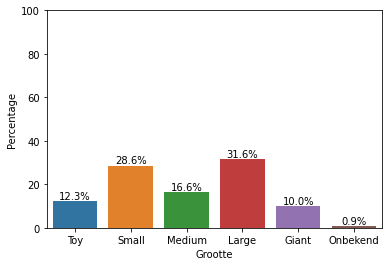

In [36]:
print(permanent_dogs["BREED SIZE"].unique())

print(permanent_dogs[permanent_dogs["BREED SIZE"]=='.'])

permanent_dogs['BREED SIZE']=permanent_dogs['BREED SIZE'].replace('Small 2', 'Small')
permanent_dogs['BREED SIZE']=permanent_dogs['BREED SIZE'].replace('Small 1', 'Toy')
permanent_dogs['BREED SIZE']=permanent_dogs['BREED SIZE'].replace('.', 'Onbekend')

size_type = CategoricalDtype(categories=["Toy", "Small", "Medium", "Large", "Giant", "Onbekend"], ordered=True)
permanent_dogs["BREED SIZE"] = permanent_dogs["BREED SIZE"].astype(size_type)

total_count = len(permanent_dogs)
percentage = permanent_dogs['BREED SIZE'].value_counts(normalize=True) * 100

plot = sns.barplot(x=percentage.index, y=percentage.values, order=size_type.categories)
plot.set_xlabel('Grootte')
plot.set_ylabel('Percentage')
plot.set(ylim=(0, 100)) 
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

### SKULL TYPE

['Meso' 'Brachy' 'Meso**' 'Doligo' 'Meso*' 'doligo' '.']
Empty DataFrame
Columns: [SEX, BREED, LITTER, BREED SIZE, SKULL TYPE, BREED CLADE, RELIABILITY (1/2), STUDY]
Index: []


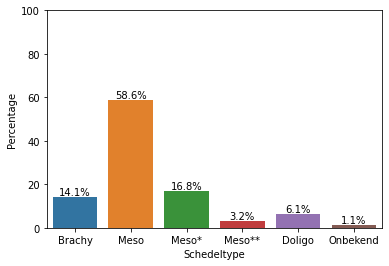

In [37]:
print(permanent_dogs["SKULL TYPE"].unique())
print(permanent_dogs[permanent_dogs["SKULL TYPE"]=='Onbekend'])

permanent_dogs['SKULL TYPE']=permanent_dogs['SKULL TYPE'].replace('doligo', 'Doligo')

skull_type = CategoricalDtype(categories=["Brachy", "Meso", "Meso*", "Meso**", "Doligo", "Onbekend"], ordered=True)
permanent_dogs["SKULL TYPE"] = permanent_dogs["SKULL TYPE"].astype(skull_type)

permanent_dogs['SKULL TYPE']=permanent_dogs['SKULL TYPE'].fillna('Onbekend')

total_count = len(permanent_dogs)
percentage = permanent_dogs['SKULL TYPE'].value_counts(normalize=True) * 100

plot = sns.barplot(x=percentage.index, y=percentage.values, order=skull_type.categories)
plot.set_xlabel('Schedeltype')
plot.set_ylabel('Percentage')
plot.set(ylim=(0, 100)) 
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

### SKULL TYPE & BREED SIZE

- Toy enkel in Meso en Meso**
- Medium enkel in Meso en Meso*
- Giant enkel in Meso en Brachy
- Meso alle types

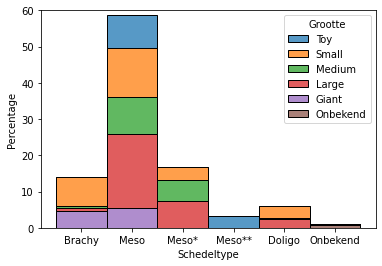

In [39]:
plot=sns.histplot(binwidth=1,
            x="SKULL TYPE",
            hue="BREED SIZE",
            data=permanent_dogs,
            stat="percent",
            multiple="stack")
plot.set_xlabel('Schedeltype')
plot.set_ylabel('Percentage')
plot.set_ylim(0,60)
sns.move_legend(plot, title='Grootte', loc='best')

### BREED CLADE 

2x niet ingevulde BREED CLADE (bij kruising) --> .

['A' 'W' 'T' 'O' 'V' 'H' 'S' '.' 'P' 'I' 'R' 'L' 'M' 'Q' 'X' 'y' 'N' 'B'
 'E' 'F' 'U' 'D' 'Y' nan]
    SEX                                   BREED  LITTER BREED SIZE SKULL TYPE  \
DOG                                                                             
435   M  Border Collie x English Cocker Spaniel  Single     Medium       Meso   
436   F         Border Collie x German Shepherd  Single     Medium       Meso   

    BREED CLADE  RELIABILITY (1/2) STUDY  
DOG                                       
435         NaN                  1  LONG  
436         NaN                  1  LONG  
Q    54
L    46
P    43
T    38
.    31
W    30
A    30
H    21
V    19
R    18
Name: BREED CLADE, dtype: int64


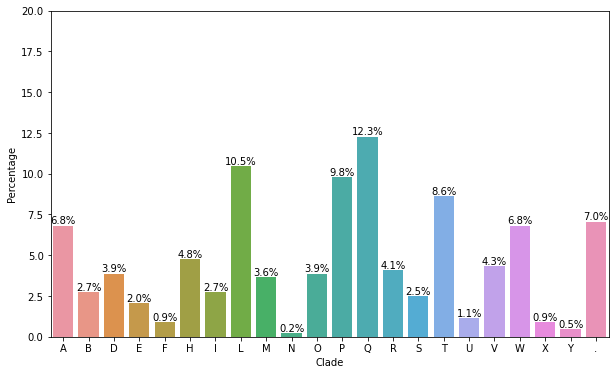

In [40]:
print(permanent_dogs["BREED CLADE"].unique())

print(permanent_dogs[permanent_dogs["BREED CLADE"].isna()])

permanent_dogs["BREED CLADE"]=permanent_dogs["BREED CLADE"].replace('y', 'Y')
permanent_dogs["BREED CLADE"]=permanent_dogs["BREED CLADE"].fillna('.')

print(permanent_dogs['BREED CLADE'].value_counts()[:10])

clade_alfa = CategoricalDtype(categories=["A", "B", "D", "E", "F", "H", "I", "L", "M", "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "."], ordered=True)
permanent_dogs["BREED CLADE"] = permanent_dogs["BREED CLADE"].astype(clade_alfa)

total_count = len(permanent_dogs)
percentage = permanent_dogs['BREED CLADE'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
plot = sns.barplot(x=percentage.index, y=percentage.values, order=clade_alfa.categories)
plot.set_xlabel('Clade')
plot.set_ylabel('Percentage')
plot.set(ylim=(0, 20)) 
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

#grid
clade_counts = permanent_dogs.groupby(['BREED CLADE', 'BREED']).size().reset_index(name='count')
breed_totals = clade_counts.groupby('BREED CLADE')['count'].sum().reset_index(name='total')
clade_counts = clade_counts.merge(breed_totals, on='BREED CLADE')
clade_counts['percentage'] = (clade_counts['count'] / clade_counts['total']) * 100

fig = px.treemap(clade_counts, path=['BREED CLADE', 'BREED'], values='count', width=1200, height=700, hover_data=['percentage'])
fig.data[0].textinfo = 'label+value+percent entry'
fig.data[0].texttemplate = '%{label}<br>%{value}<br>%{customdata[0]:.1f}%'
fig.update_traces(textfont_size=16)
fig.update_layout(margin=dict(t=0, l=0, r=0, b=25))
fig.show()

### RELIABILITY

1    368
2     72
Name: RELIABILITY (1/2), dtype: int64
[2 1]


<AxesSubplot:xlabel='RELIABILITY (1/2)', ylabel='count'>

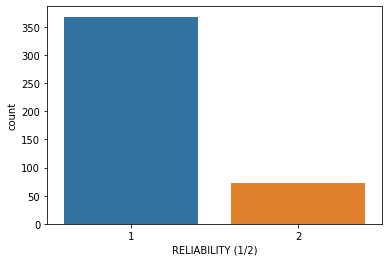

In [41]:
print(permanent_dogs['RELIABILITY (1/2)'].value_counts())

print(permanent_dogs['RELIABILITY (1/2)'].unique())

sns.countplot(data=permanent_dogs, x="RELIABILITY (1/2)")

### STUDY

long komt meest voor

['SINGLE' 'LONG' '< 5']
LONG      269
SINGLE    143
< 5        28
Name: STUDY, dtype: int64


Text(0, 0.5, 'Aantal')

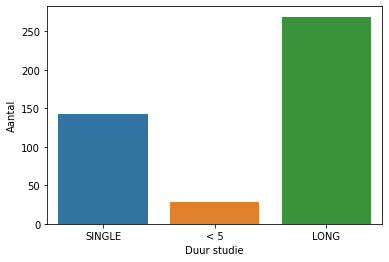

In [42]:
print(permanent_dogs["STUDY"].unique())
print(permanent_dogs["STUDY"].value_counts())

study_seq = CategoricalDtype(categories=['SINGLE', '< 5', 'LONG'], ordered=True)
permanent_dogs["STUDY"] = permanent_dogs["STUDY"].astype(study_seq)

plot=sns.countplot(data=permanent_dogs, x="STUDY")
plot.set_xlabel('Duur studie')
plot.set_ylabel('Aantal')

## Teeth

### Overzicht volledige dataset

Unnamed kolom

Per tand nu drie stages (behalve first premolars and all molars)

In [167]:
permanent_teeth.head()

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS,Unnamed: 9
DOG,,,,,,,,,
1,201,MAX,L,1,1,91,93,1,NaN
1,201,MAX,L,1,2,93,93,1,NaN
1,201,MAX,L,1,3,99,101,1,NaN
1,101,MAX,R,1,1,91,93,1,NaN
1,101,MAX,R,1,2,93,93,1,NaN


In [44]:
permanent_teeth.drop('Unnamed: 9', axis=1, inplace=True)

In [169]:
permanent_teeth.shape

(49280, 8)

Geen null waarden

In [170]:
permanent_teeth.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 49280 entries, 1 to 440
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   TOOTH NUMBER    49280 non-null  int64 
 1   MAX/MAND        49280 non-null  object
 2   SIDE (L/R)      49280 non-null  object
 3   POSITION        49280 non-null  int64 
 4   DEVELOPM STAGE  49280 non-null  int64 
 5   LOWER           49280 non-null  object
 6   UPPER           49280 non-null  object
 7   SENS            49280 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.4+ MB


Opvallende bij desribe:
- Meest werden MAND & L opgevolgd
- LOWER, UPPER & SENS zijn objecten en geen integers --> . vervangen door NaN

In [117]:
permanent_teeth.describe(include=["object"])

,MAX/MAND,SIDE (L/R),LOWER,UPPER,SENS
count,49280,49280,49280,49280,49280
unique,2,2,219,213,7
top,MAND,L,.,.,1
freq,25520,24640,18676,23273,21879


### TOOTH NUMBER

Opvallend bepaalde tanden minder opgevolgd dan andere --> dit dus omdat sommige geen eerste stage hebben

In [ ]:
permanent_teeth["TOOTH NUMBER"].value_counts()

201    1320
404    1320
408    1320
308    1320
108    1320
208    1320
407    1320
307    1320
107    1320
207    1320
406    1320
306    1320
101    1320
206    1320
106    1320
304    1320
103    1320
301    1320
401    1320
202    1320
302    1320
402    1320
203    1320
102    1320
303    1320
204    1320
104    1320
403    1320
409     880
311     880
410     880
310     880
110     880
210     880
109     880
309     880
209     880
105     880
305     880
405     880
205     880
411     880
Name: TOOTH NUMBER, dtype: int64

### MAX/MAND

Aantal tanden per kwadrant verschilt van boven (2 molaren)-en onderkaak (3 molaren)

In [ ]:
permanent_teeth["MAX/MAND"].value_counts()

MAND    25520
MAX     23760
Name: MAX/MAND, dtype: int64

### SIDE (L/R)

In [ ]:
permanent_teeth["SIDE (L/R)"].value_counts()

L    24640
R    24640
Name: SIDE (L/R), dtype: int64

### POSITION

In [ ]:
permanent_teeth["POSITION"].value_counts()

1     5280
2     5280
3     5280
4     5280
6     5280
7     5280
8     5280
5     3520
9     3520
10    3520
11    1760
Name: POSITION, dtype: int64

### DEVELOPMENT STAGE

In [ ]:
permanent_teeth["DEVELOPM STAGE"].value_counts()

2    18480
3    18480
1    12320
Name: DEVELOPM STAGE, dtype: int64

### LOWER

In [45]:
permanent_teeth["LOWER"]=permanent_teeth["LOWER"].replace('.', np.nan)

Wordt nog steeds als object gezien

In [221]:
permanent_teeth["LOWER"].describe()

count     30604
unique      218
top         133
freq        725
Name: LOWER, dtype: int64

12O ipv 120?

In [222]:
permanent_teeth["LOWER"].unique()

array([91, 93, 99, 98, 100, 107, 122, 121, 131, 119, 136, 114, 129, nan,
       132, 105, 117, 110, 118, 111, 126, 133, 147, 140, 141, 127, 120,
       128, 135, 149, 142, 143, 138, 106, 112, 113, 101, 102, 109, 115,
       125, 134, 137, 108, 116, 123, 154, 155, 151, 145, 159, 150, 163,
       156, 152, 146, 153, 157, 124, 130, 170, 162, 169, 160, 168, 166,
       173, 139, 144, 158, 165, 164, 148, 161, 103, 171, 174, 167, 104,
       178, 179, '138', '116', 177, 172, 196, 181, 193, 195, 202, 188,
       190, 197, 206, 214, 185, 180, '155', '172', '146', '154', '161',
       '114', '115', '122', '147', '106', '123', '109', '113', '111',
       '118', '110', '117', '120', '125', '132', '151', '160', '112',
       '130', '141', '143', '150', '127', '148', '162', 184, '182', '189',
       '137', '156', '134', '119', '104', '103', '105', 95, '139', '135',
       '149', '133', '124', '131', '142', '121', '152', '136', 96, 97,
       175, '140', '144', '153', '159', '166', '158', '165', '17

In [46]:
permanent_teeth["LOWER"]=permanent_teeth["LOWER"].replace('12O', 120)

In [47]:
permanent_teeth["LOWER"]=pd.to_numeric(permanent_teeth["LOWER"])

Er zijn honden met alle LOWER values ingevuld en ook honden met alle LOWER values NaN

Meer honden met LOWER NaN te zien aan gem en %

In [225]:
permanent_teeth["LOWER"].isnull().groupby(permanent_teeth.index).sum().astype(int).describe()

count    440.000000
mean      42.445455
std       32.663421
min        0.000000
25%       12.750000
50%       37.500000
75%       69.250000
max      112.000000
Name: LOWER, dtype: float64

Gem ligt hoger aangezien het over permanent gebit gaat

In [226]:
permanent_teeth["LOWER"].describe()

count    30604.000000
mean       139.077768
std         19.070130
min         85.000000
25%        125.000000
50%        139.000000
75%        152.000000
max        214.000000
Name: LOWER, dtype: float64

fouten eruithalen

Mag omgewisseld bij: pup 144 en 291

Pup 209: 156 vervangen door “.”

Pup 249: 132 vervangen door “.”

In [48]:
permanent_teeth["UPPER"]=permanent_teeth["UPPER"].replace('.', np.nan)
permanent_teeth["UPPER"]=pd.to_numeric(permanent_teeth["UPPER"])

In [49]:
condition = (permanent_teeth['LOWER'] > permanent_teeth['UPPER']) & (~permanent_teeth.index.isin([209, 249]))
permanent_teeth.loc[condition, ['LOWER', 'UPPER']] = permanent_teeth.loc[condition, ['UPPER', 'LOWER']].values

permanent_teeth.loc[(permanent_teeth.index == 209) & (permanent_teeth['TOOTH NUMBER'] == 206) & (permanent_teeth['DEVELOPM STAGE'] == 1), 'LOWER'] = np.nan
permanent_teeth.loc[(permanent_teeth.index == 209) & (permanent_teeth['TOOTH NUMBER'] == 206) & (permanent_teeth['DEVELOPM STAGE'] == 1), 'SENS'] = 0
permanent_teeth.loc[(permanent_teeth.index == 209) & (permanent_teeth['TOOTH NUMBER'] == 106) & (permanent_teeth['DEVELOPM STAGE'] == 1), 'LOWER'] = np.nan
permanent_teeth.loc[(permanent_teeth.index == 209) & (permanent_teeth['TOOTH NUMBER'] == 106) & (permanent_teeth['DEVELOPM STAGE'] == 1), 'SENS'] = 0
permanent_teeth.loc[(permanent_teeth.index == 249) & (permanent_teeth['TOOTH NUMBER'] == 206) & (permanent_teeth['DEVELOPM STAGE'] == 1), 'UPPER'] = np.nan
permanent_teeth.loc[(permanent_teeth.index == 249) & (permanent_teeth['TOOTH NUMBER'] == 206) & (permanent_teeth['DEVELOPM STAGE'] == 1), 'SENS'] = 2

DEVELOPM STAGE 1 & 2 gelijkaardig

3 wat hoger

                  count        mean        std   min    25%    50%    75%  \
DEVELOPM STAGE                                                              
1                7205.0  134.798612  18.731825  85.0  121.0  134.0  148.0   
2               11808.0  136.208333  18.230755  85.0  123.0  136.0  149.0   
3               11589.0  144.658124  18.778755  88.0  131.0  145.0  158.0   

                  max  
DEVELOPM STAGE         
1               196.0  
2               202.0  
3               214.0  


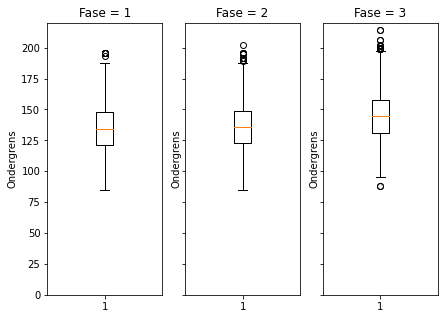

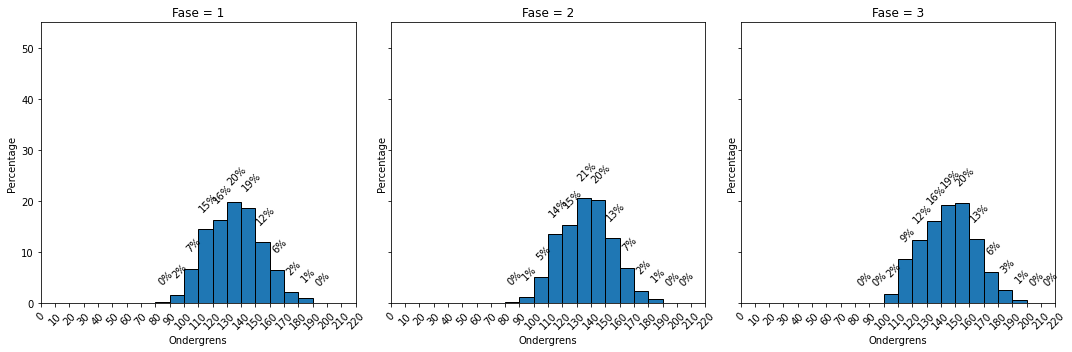

In [229]:
# group dataframe by quality values
dogs_developm_stage = permanent_teeth[permanent_teeth["LOWER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["LOWER"].describe())

# create a sub plot for each quality group
fig, axes = plt.subplots(ncols=len(dogs_developm_stage), 
                         figsize=[7,5],
                         sharey=True)

# loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    ax.boxplot(data['LOWER'])
    ax.set_title(f"Fase = {stage}")
    ax.set_ylabel('Ondergrens')
    ax.set_ylim(0,220)



fig, axes = plt.subplots(ncols=len(dogs_developm_stage), 
                         figsize=[15,5], sharey=True)
# Loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    bin_edges = range(int(min(data['LOWER'])) // 10 * 10, int(max(data['LOWER'])) // 10 * 10 + 20, 10)
    # Calculate the histogram with density=True for percentage
    counts, bins, patches = ax.hist(data['LOWER'], align='mid', edgecolor='black', bins=bin_edges, density=True)
    # Convert density to percentage
    bin_width = bins[1] - bins[0]  # Assuming bins are uniform
    counts_percent = counts * bin_width * 100  # Multiply by bin width and 100 to get percentage
    # Update the bars to represent percentages
    for patch, count in zip(patches, counts_percent):
        patch.set_height(count)
    # Annotate percentage values above the bars
    for patch in patches:
        height = patch.get_height()
        x_position = patch.get_x() + patch.get_width() / 2  # Position at the center of the bar
        ax.text(x_position+2, height + 3, f'{height:.0f}%', ha='center', va='bottom', fontsize=10,rotation=45)
    ax.set_title(f"Fase = {stage}")
    ax.set_xlabel('Ondergrens')
    ax.set_ylabel("Percentage")
    ax.set_xlim(0, 220)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(MultipleLocator(10))
plt.tight_layout()

PER TAND

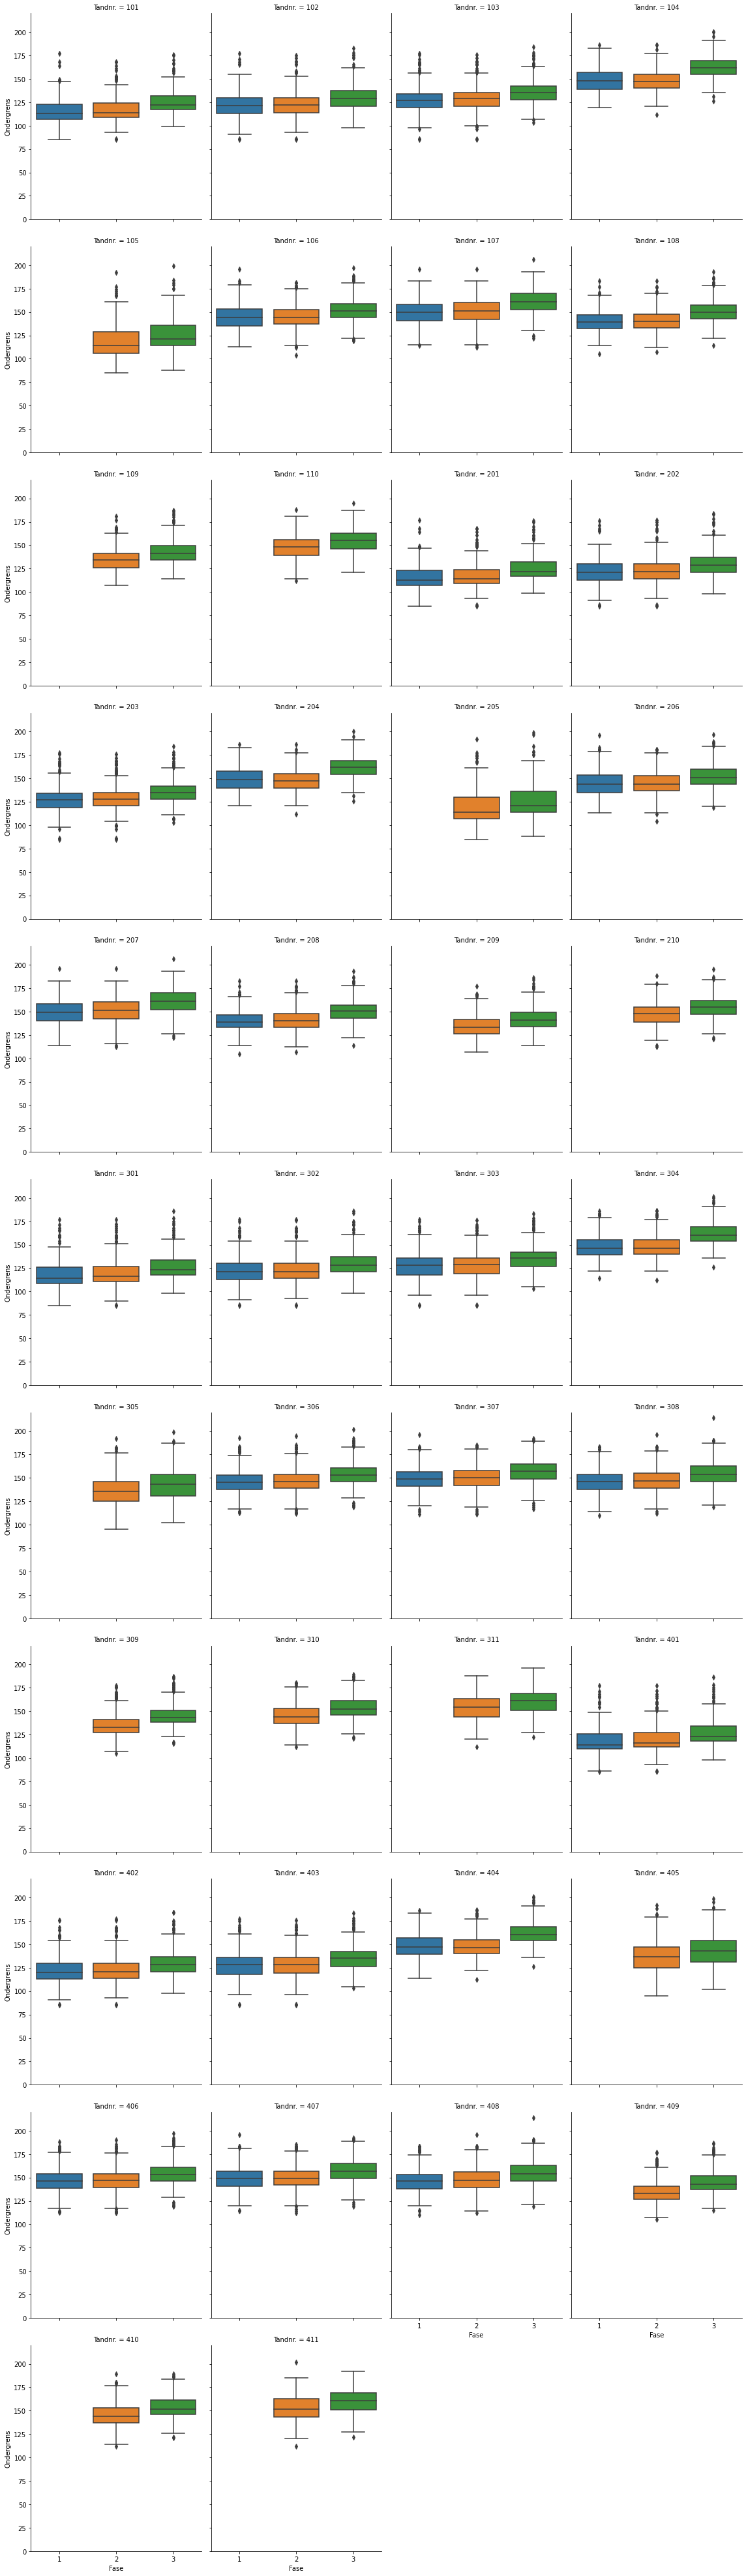

In [230]:
plot=sns.catplot(
    data=permanent_teeth, x='DEVELOPM STAGE', y='LOWER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Ondergrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,220))
plot.set_titles("Tandnr. = {col_name}")

### UPPER

In [50]:
permanent_teeth["UPPER"]=permanent_teeth["UPPER"].replace('.', np.nan)
permanent_teeth["UPPER"]=pd.to_numeric(permanent_teeth["UPPER"])

In [128]:
permanent_teeth["UPPER"].describe()

count    26006.000000
mean       142.848035
std         19.187094
min         88.000000
25%        129.000000
50%        143.000000
75%        157.000000
max        231.000000
Name: UPPER, dtype: float64

                  count        mean        std   min    25%    50%    75%  \
DEVELOPM STAGE                                                              
1                5776.0  138.119114  18.469453  92.0  125.0  138.0  151.0   
2               10096.0  139.750693  18.282483  93.0  127.0  140.0  153.0   
3               10132.0  148.629096  19.019599  88.0  135.0  149.0  162.0   

                  max  
DEVELOPM STAGE         
1               197.0  
2               199.0  
3               231.0  


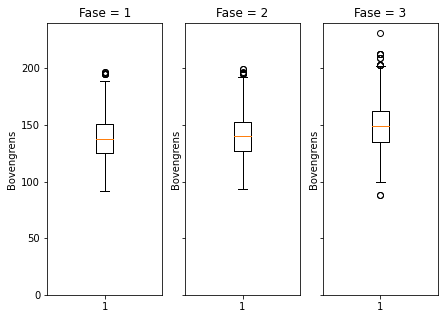

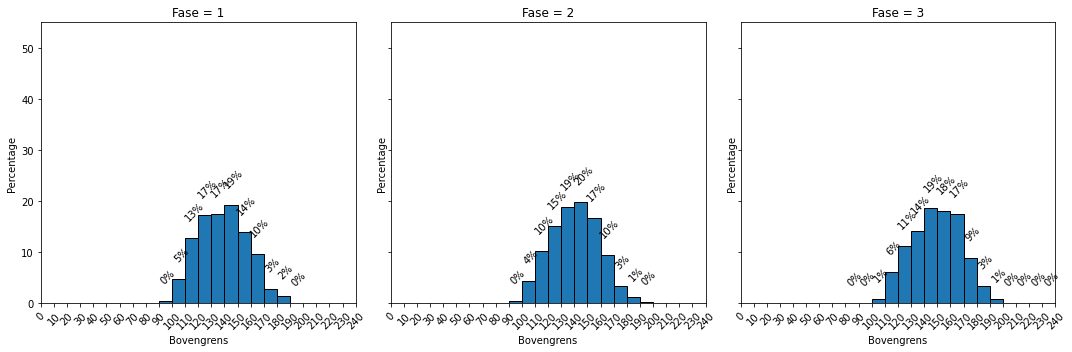

In [157]:
# group dataframe by quality values
dogs_developm_stage = permanent_teeth[permanent_teeth["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["UPPER"].describe())

# create a sub plot for each quality group
fig, axes = plt.subplots(ncols=len(dogs_developm_stage), 
                         figsize=[7,5],
                         sharey=True)

# loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    ax.boxplot(data['UPPER'])
    ax.set_title(f"Fase = {stage}")
    ax.set_ylabel('Bovengrens')
    ax.set_ylim(0, 240)

fig, axes = plt.subplots(ncols=3, 
                         figsize=[15, 5], sharey=True)
# Loop over axes and quality groups together
for ax, (stage, data) in zip(axes, dogs_developm_stage):
    bin_edges = range(int(min(data['UPPER'])) // 10 * 10, int(max(data['UPPER'])) // 10 * 10 + 20, 10)
    # Calculate the histogram with density=True for percentage
    counts, bins, patches = ax.hist(data['UPPER'], align='mid', edgecolor='black', bins=bin_edges, density=True)
    # Convert density to percentage
    bin_width = bins[1] - bins[0]  # Assuming bins are uniform
    counts_percent = counts * bin_width * 100  # Multiply by bin width and 100 to get percentage
    # Update the bars to represent percentages
    for patch, count in zip(patches, counts_percent):
        patch.set_height(count)
    # Annotate percentage values above the bars
    for patch in patches:
        height = patch.get_height()
        x_position = patch.get_x() + patch.get_width() / 2  # Position at the center of the bar
        ax.text(x_position+2, height + 3, f'{height:.0f}%', ha='center', va='bottom', fontsize=10,rotation=45)
    ax.set_title(f"Fase = {stage}")
    ax.set_xlabel('Bovengrens')
    ax.set_ylabel("Percentage")
    ax.set_xlim(0, 240)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(MultipleLocator(10))
plt.tight_layout()

In [129]:
permanent_teeth[permanent_teeth["UPPER"]==88]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
231,205,MAX,L,5,3,88.0,88.0,1
231,105,MAX,R,5,3,88.0,88.0,1


PER TAND

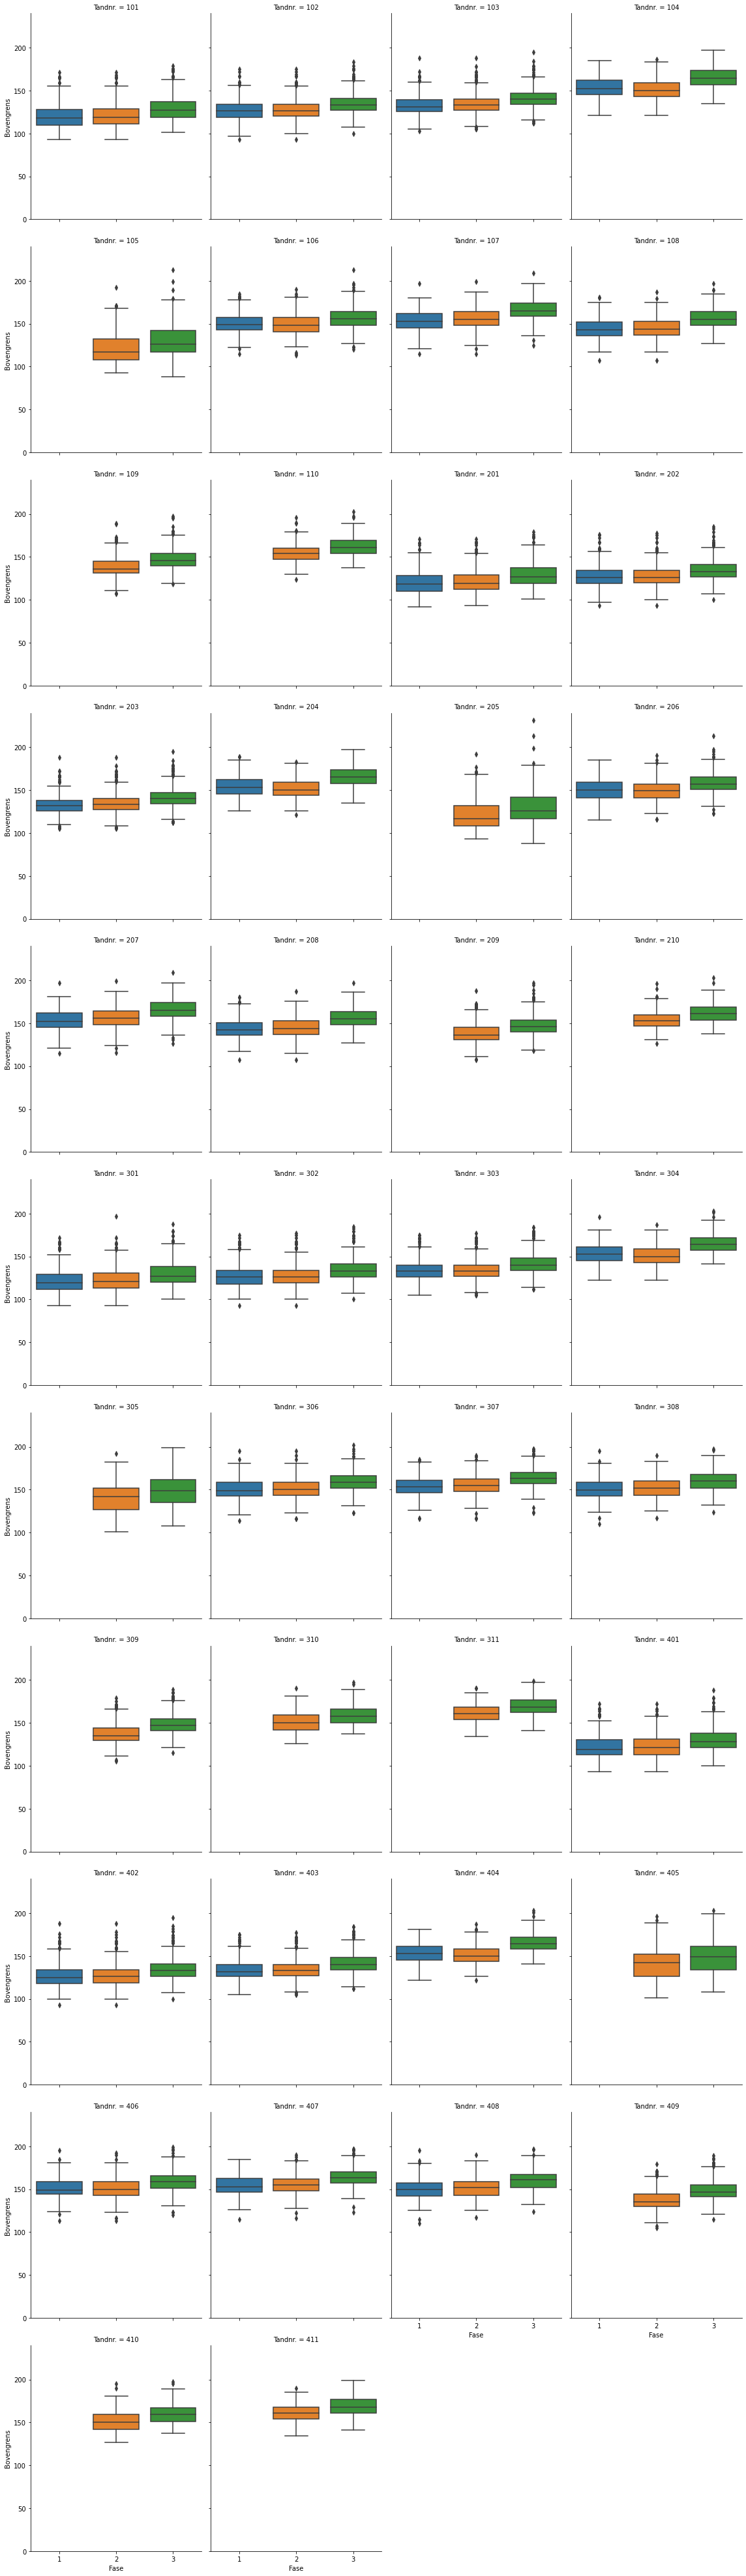

In [159]:
plot=sns.catplot(
    data=permanent_teeth, x='DEVELOPM STAGE', y='UPPER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Bovengrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,240))
plot.set_titles("Tandnr. = {col_name}")

### SENS

In [212]:
permanent_teeth["SENS"].unique()

array(['1', '2', '.', '0', 0, 2, 1], dtype=object)

In [51]:
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace('0',0)
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace('1',1)
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace('2',2)

- Meest interval en .
- Minst left

In [52]:
permanent_teeth["SENS"].value_counts()

1    21903
.    14575
2     8700
0     4102
Name: SENS, dtype: int64

In [182]:
permanent_teeth[(permanent_teeth["SENS"]=='.')].head()

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
1,306,MAND,L,6,1,NaN,NaN,.
1,306,MAND,L,6,2,NaN,NaN,.
1,306,MAND,L,6,3,NaN,NaN,.
1,406,MAND,R,6,1,NaN,NaN,.
1,406,MAND,R,6,2,NaN,NaN,.


In [183]:
permanent_teeth[((permanent_teeth["LOWER"]==permanent_teeth["UPPER"]) & (permanent_teeth["SENS"]!='.'))].head()

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS
DOG,,,,,,,,
1,201,MAX,L,1,2,93.0,93.0,1
1,101,MAX,R,1,2,93.0,93.0,1
1,301,MAND,L,1,2,93.0,93.0,1
1,401,MAND,R,1,2,93.0,93.0,1
1,202,MAX,L,2,2,93.0,93.0,1


Nieuwe waarden def:
- 0 = gn censoring
- 1 = geen info
- 2 = left
- 3 = interval
- 4 = right

In [53]:
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace(2, 4)
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace(1, 3)
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace(0, 2)
permanent_teeth["SENS"]=permanent_teeth["SENS"].replace('.', 1)

In [54]:
permanent_teeth.loc[((permanent_teeth["LOWER"]==permanent_teeth["UPPER"]) & (permanent_teeth["LOWER"].notna()), "SENS")] = 0
permanent_teeth.loc[((permanent_teeth["LOWER"].isna()) & (permanent_teeth["UPPER"].isna()) & (permanent_teeth["SENS"]!=0), "SENS")] = 1
permanent_teeth.loc[((permanent_teeth["LOWER"].isna()) & (permanent_teeth["UPPER"].notna()), "SENS")] = 2
permanent_teeth.loc[((permanent_teeth["LOWER"].notna()) & (permanent_teeth["UPPER"].notna()) & (permanent_teeth["LOWER"]!=permanent_teeth["UPPER"]), "SENS")] = 3
permanent_teeth.loc[((permanent_teeth["LOWER"].notna()) & (permanent_teeth["UPPER"].isna()), "SENS")] = 4

Nu left wel meest voorkomend

In [55]:
permanent_teeth["SENS"].value_counts()

1    14575
3    12106
0     9797
4     8699
2     4103
Name: SENS, dtype: int64

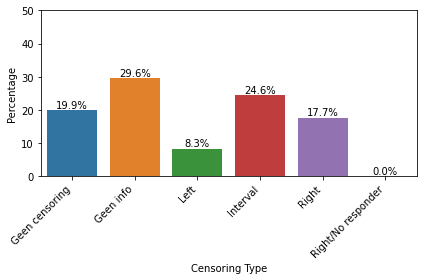

In [246]:
categories = [0,1,2,3,4,5]

# Calculate percentages
percentage = permanent_teeth["SENS"].value_counts(normalize=True) * 100

# Reindex to include all categories, filling missing ones with 0
percentage = percentage.reindex(categories, fill_value=0)

# Plot percentages
plot = sns.barplot(x=percentage.index, y=percentage.values, order=categories)

# Set x-axis labels
plot.set_xticklabels(['Geen censoring', 'Geen info', 'Left', 'Interval', 'Right', 'Right/No responder'], rotation=45, ha='right')
plot.set_xlabel('Censoring Type')
plot.set_ylabel('Percentage')
plot.set_ylim(0,50)
# Add percentage labels above the bars
for p in plot.patches:
    plot.annotate(f'{p.get_height():.1f}%', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()  # Adjust layout to prevent overlap

#### 0: geen censoring (LOWER==UPPER)

In [247]:
df_no_censoring = permanent_teeth[permanent_teeth["SENS"]==0]
df_no_censoring.index.value_counts()

265    111
128    110
434     88
246     77
158     73
      ... 
350      2
342      1
362      1
380      1
82       1
Name: DOG, Length: 361, dtype: int64

In [248]:
# group dataframe by quality values
dogs_developm_stage = df_no_censoring[df_no_censoring["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["UPPER"].describe())

                 count        mean        std   min    25%    50%    75%  \
DEVELOPM STAGE                                                             
1               1410.0  134.853191  19.245207  92.0  120.0  134.0  149.0   
2               4607.0  138.321250  18.396066  93.0  126.0  139.0  151.0   
3               3780.0  145.936508  18.971900  88.0  132.0  147.0  160.0   

                  max  
DEVELOPM STAGE         
1               183.0  
2               195.0  
3               202.0  


verband met volgorde uitkomen

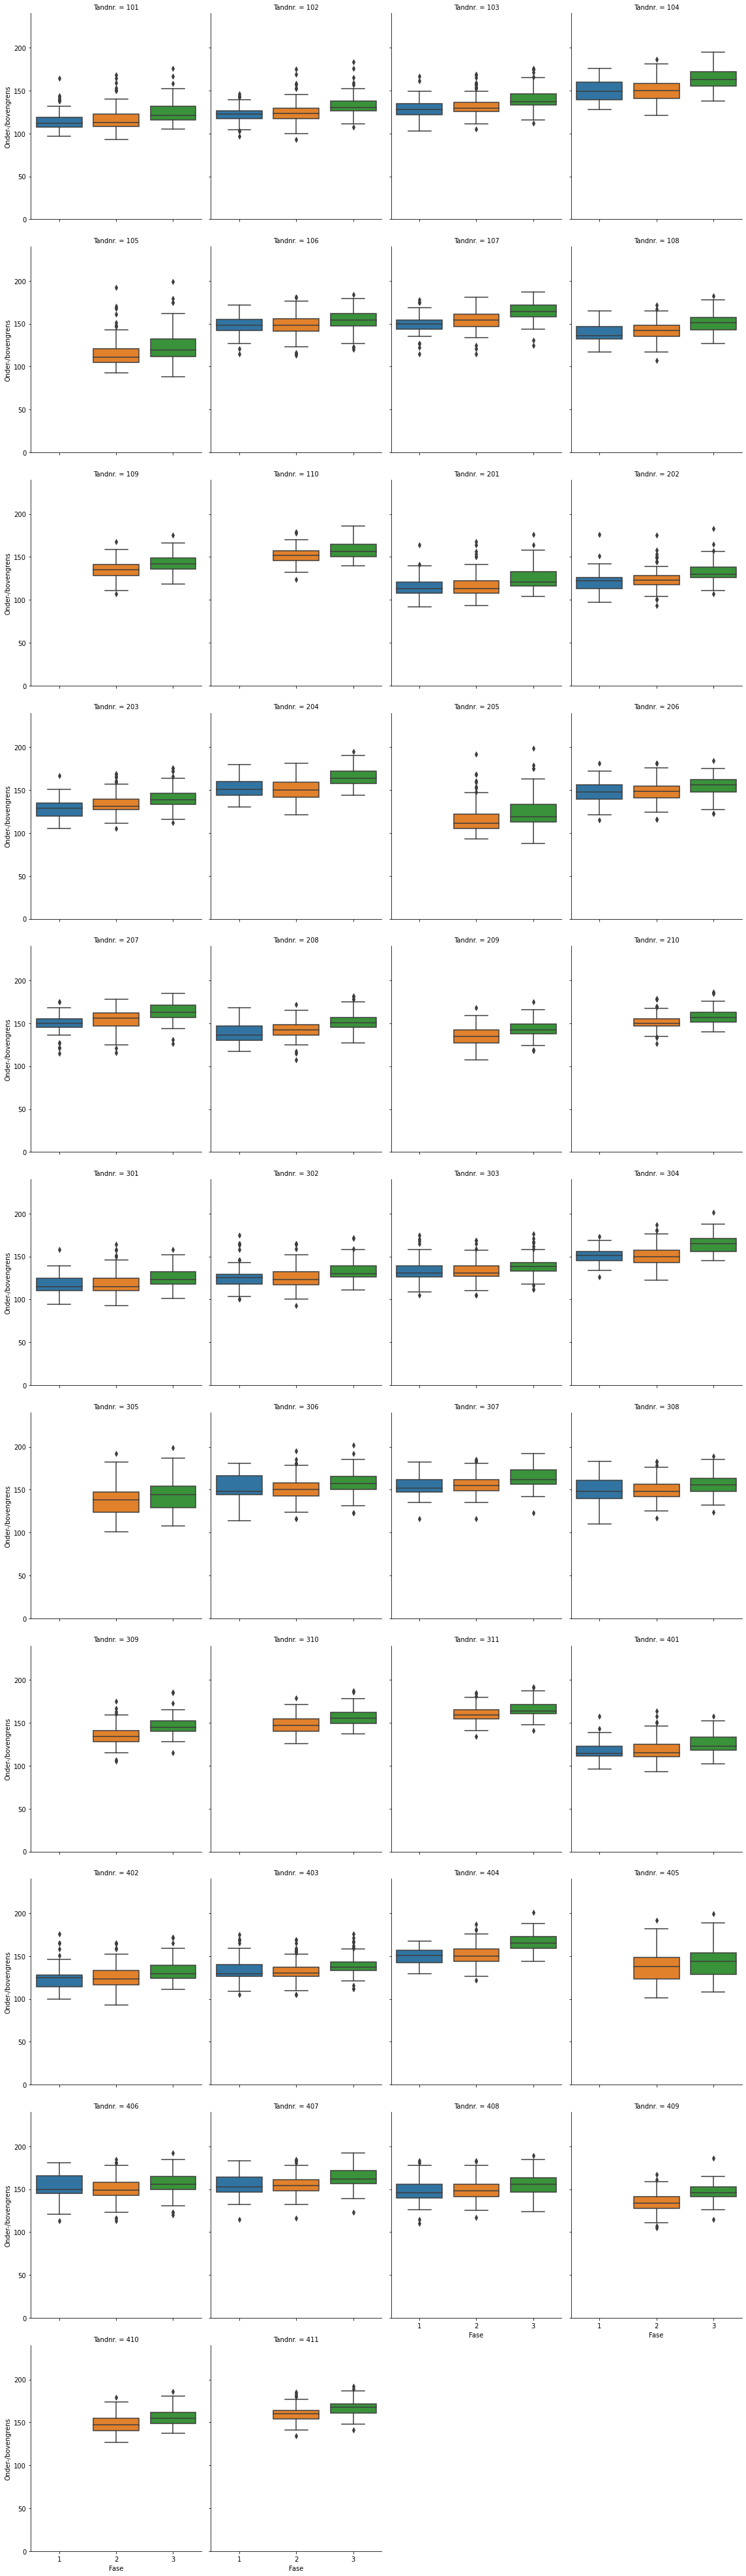

In [200]:
plot=sns.catplot(
    data=df_no_censoring, x='DEVELOPM STAGE', y='LOWER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Onder-/bovengrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,240))
plot.set_titles("Tandnr. = {col_name}")

#### 2: left censoring

enkel eindpunt plotten

In [249]:
df_left_censoring = permanent_teeth[(permanent_teeth["SENS"]==2)&(permanent_teeth["UPPER"].notna())]
df_left_censoring.index.value_counts()

251    74
418    73
430    64
189    62
96     56
       ..
126     1
116     1
325     1
336     1
222     1
Name: DOG, Length: 234, dtype: int64

In [255]:
dogs_developm_stage = df_left_censoring[df_left_censoring["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["UPPER"].describe())

                 count        mean        std    min    25%    50%    75%  \
DEVELOPM STAGE                                                              
1                912.0  135.885965  17.997809   95.0  121.0  133.0  147.0   
2               1520.0  142.117763  17.288855  102.0  129.0  141.5  157.0   
3               1671.0  150.852783  17.427966  106.0  137.0  152.0  166.0   

                  max  
DEVELOPM STAGE         
1               195.0  
2               190.0  
3               213.0  


Bij sommige tanden heel klein boxplot --> kan leeftijd mss wel makkelijk uit afgeleid worden bij die tanden

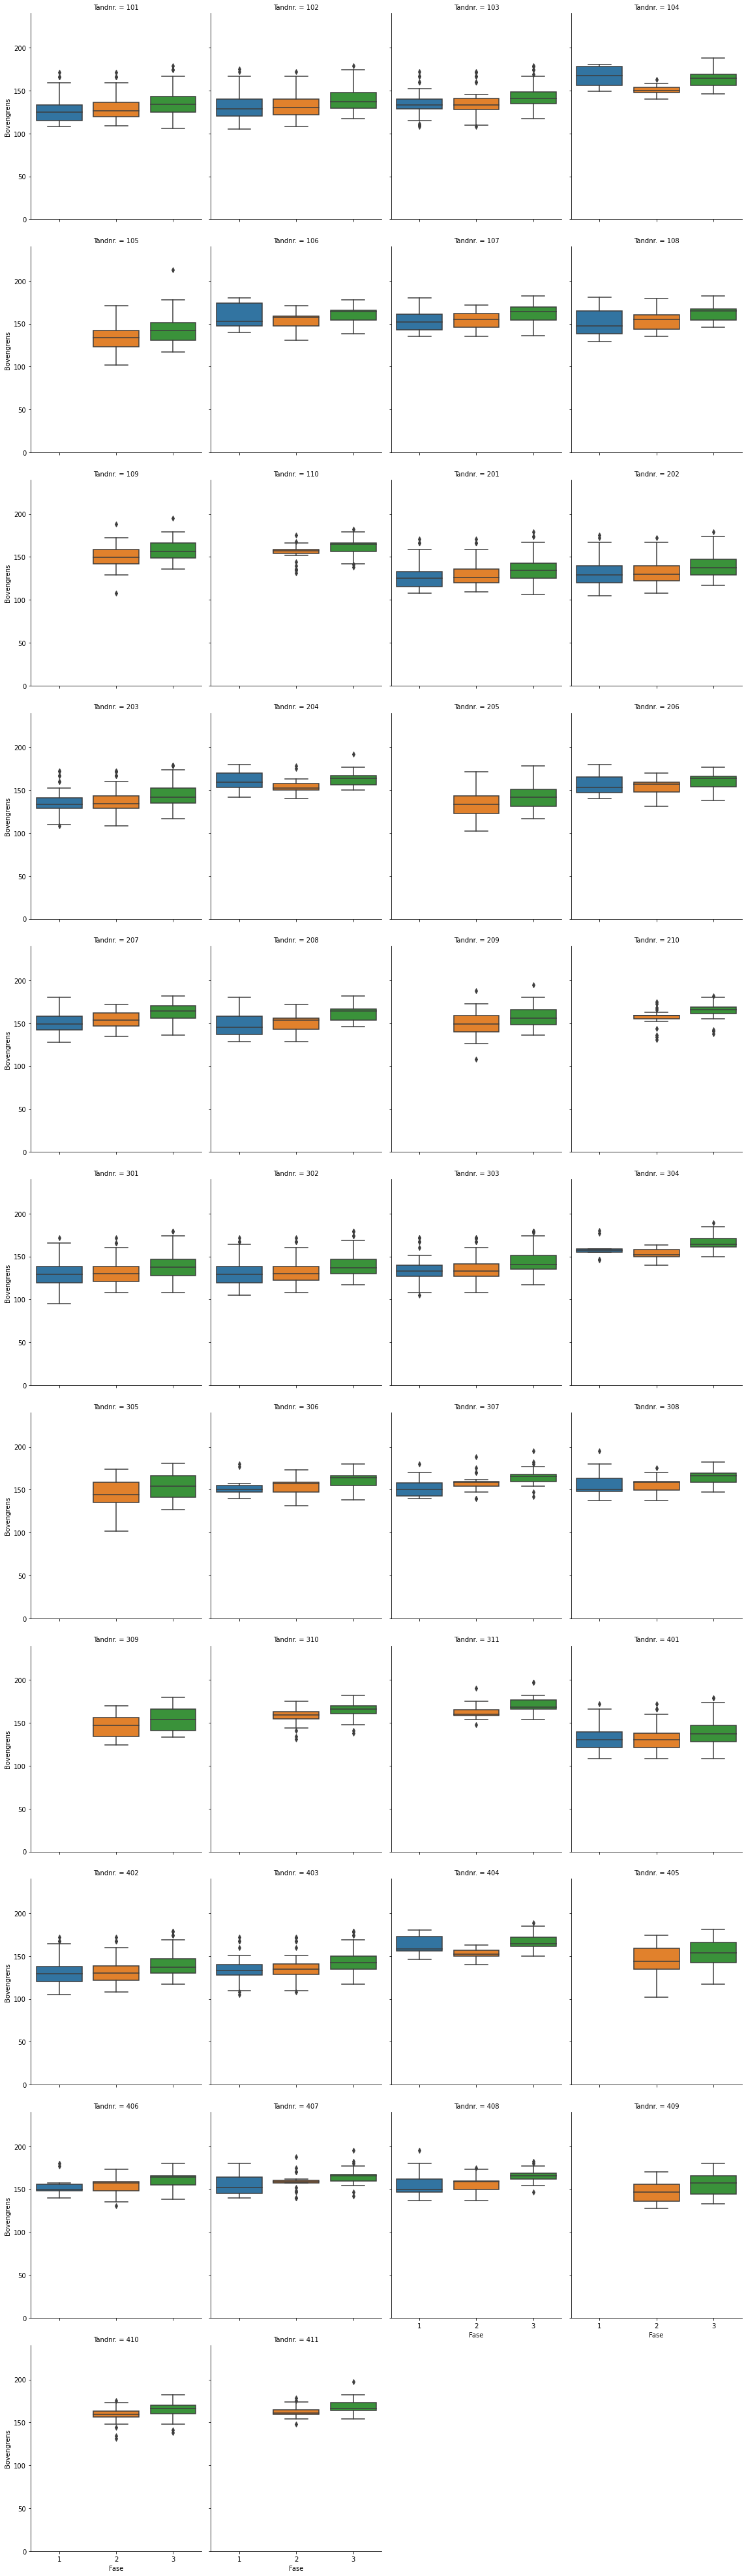

In [219]:
plot=sns.catplot(
    data=df_left_censoring, x='DEVELOPM STAGE', y='UPPER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Bovengrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,240))
plot.set_titles("Tandnr. = {col_name}")

#### 3: inteval censoring

In [256]:
df_interval_censoring = permanent_teeth[permanent_teeth["SENS"]==3]
df_interval_censoring.index.value_counts()

351    103
352     92
66      89
47      86
395     82
      ... 
338      1
214      1
391      1
306      1
265      1
Name: DOG, Length: 366, dtype: int64

In [259]:
dogs_developm_stage = df_interval_censoring[df_interval_censoring["UPPER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["LOWER"].describe())
print(dogs_developm_stage["UPPER"].describe())

                 count        mean        std   min    25%    50%    75%  \
DEVELOPM STAGE                                                             
1               3454.0  134.728720  17.835776  90.0  122.0  135.0  148.0   
2               3970.0  134.236524  18.104933  86.0  121.0  134.0  147.0   
3               4682.0  143.543998  19.023285  95.0  129.0  143.0  157.0   

                  max  
DEVELOPM STAGE         
1               196.0  
2               196.0  
3               206.0  
                 count        mean        std    min    25%    50%    75%  \
DEVELOPM STAGE                                                              
1               3454.0  140.045165  18.014723   93.0  127.0  140.0  153.0   
2               3970.0  140.503275  18.383190   97.0  127.0  140.0  154.0   
3               4682.0  150.008757  19.350955  100.0  136.0  150.0  163.0   

                  max  
DEVELOPM STAGE         
1               197.0  
2               199.0  
3               2

<Figure size 576x432 with 0 Axes>

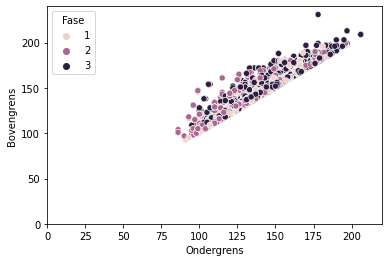

<Figure size 576x432 with 0 Axes>

In [260]:
plot=sns.scatterplot(data=df_interval_censoring, x="LOWER", y="UPPER", hue="DEVELOPM STAGE")
plot.set(ylim=(0,240))
plot.set(xlim=(0,220))
plot.set_xlabel('Ondergrens')
plot.set_ylabel('Bovengrens')
plot.legend(title='Fase')
plt.figure(figsize=(8, 6))

In [261]:
df_interval_censoring[df_interval_censoring["LOWER"]>df_interval_censoring["UPPER"]]

,TOOTH NUMBER,MAX/MAND,SIDE (L/R),POSITION,DEVELOPM STAGE,LOWER,UPPER,SENS,Unnamed: 9
DOG,,,,,,,,,


#### 4: right censoring

enkel startpunt plotten

In [262]:
df_right_censoring = permanent_teeth[(permanent_teeth["SENS"]==4)&(permanent_teeth["LOWER"].notna())]
df_right_censoring.index.value_counts()

332    112
333    108
428    104
426     97
67      96
      ... 
287      1
269      1
210      1
116      1
133      1
Name: DOG, Length: 357, dtype: int64

In [263]:
dogs_developm_stage = df_right_censoring[df_right_censoring["LOWER"]<400].groupby('DEVELOPM STAGE')
print(dogs_developm_stage["LOWER"].describe())

                 count        mean        std    min    25%    50%    75%  \
DEVELOPM STAGE                                                              
1               2341.0  134.868859  19.692104   85.0  119.0  134.0  146.0   
2               3231.0  135.618384  17.834104   85.0  125.0  136.0  146.0   
3               3127.0  144.780940  18.065451  102.0  134.0  145.0  155.0   

                  max  
DEVELOPM STAGE         
1               196.0  
2               202.0  
3               214.0  


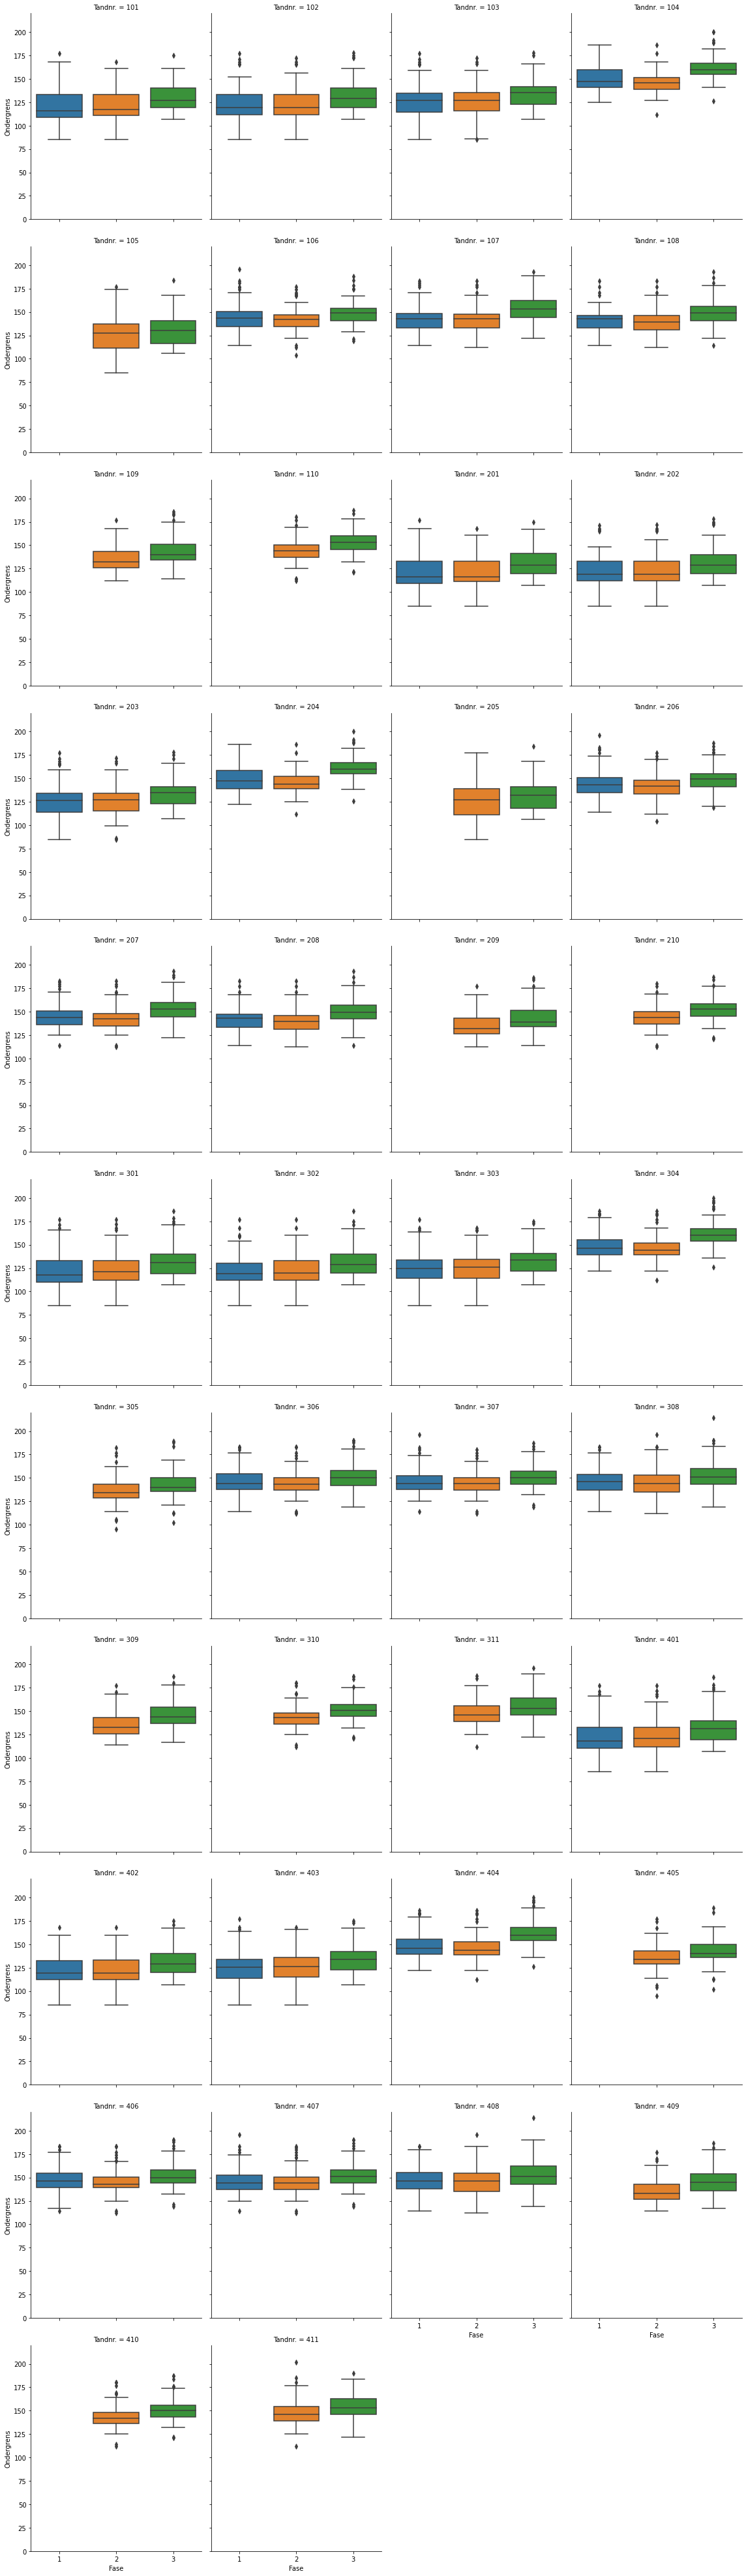

In [292]:
plot=sns.catplot(
    data=df_right_censoring, x='DEVELOPM STAGE', y='LOWER',
    col='TOOTH NUMBER', kind='box', col_wrap=4, aspect=0.8)
plot.set_ylabels('Ondergrens')
plot.set_xlabels('Fase')
plot.set(ylim=(0,220))
plot.set_titles("Tandnr. = {col_name}")

correlation matrix

<AxesSubplot:>

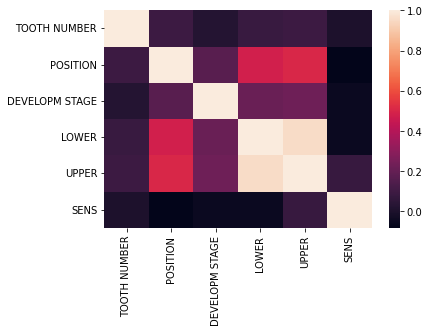

In [119]:
corr = permanent_teeth.corr()
sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

## Wegschrijven dataframes

In [56]:
with pd.ExcelWriter('../data/permanent_EDA_clean.xlsx') as writer:
   permanent_dogs.to_excel(writer, sheet_name='dogs')
   permanent_teeth.to_excel(writer, sheet_name='teeth')

## Honden in beide studies

In de excels van permanent dentition en deciduous dentition die je al hebt staat resp. in kolom E  en kolom D van het blad dog characteristics vermeld van welk nestje de pup afkomstig is. Zo kan je al opzoeken welke data van beide gebitstypes van een zelfde pup waren, en welke pups nestgenootjes waren.

Bij deciduous is enkel de litter gedef, niet hoeveelste hond uit de litter die is --> ervan uitgaan dat nr. gwn oplopend is? Dus eerste hond die litter waarde heeft, is hond 1 van die litter

OPMERKINGEN:
- beagle info is fout!
- van sommige honden is het niet zeker welke ze waren uit deciduous (of, ...) (is ook niet opvulbaar uit ruwe databron)
- best om apart te houden?

In [26]:
deciduous_dogs['LITTER'].unique()

array(['Single', 'Aussie 1', 'beagle 1', 'beagle 2', 'beagle 3',
       'beagle 4', 'beagle 5', 'beagle 6', 'beagle 7', 'Bernese 1',
       'Bernese 2', 'Bernese 3', 'Bernese 4', 'Bernese 5', 'Bernese 6',
       'Bernese 7', 'Bernese 8', 'Bernese 9', 'Bernese 10', 'Bernese 11',
       'Bichon 1', 'BC 1', 'BC 2', 'BC 12', 'BC HH1', 'Bull T 1',
       'CKCH 1', 'CKCH 2', 'CKCH 3', 'CKCH 4', 'CKCH 5',
       'Chinese Crested 1', 'Chihua 1', 'Chihua 2', 'Chihua 3',
       'Chihua 4', 'Chihua 5', 'Chihua 6', 'Chihua 7', 'Chihua 8',
       'Chihua 9', 'Drent 1', 'Drent 2', 'Hollandse H 1', 'Hollandse H 2',
       'Hollandse H 3', 'Engelse Bulld 1', 'Engelse cocker 1',
       'Engelse cocker 2', 'ESS 3', 'ESS 4', 'ESS 5', 'ESS 6', 'ESS 7',
       'FrB 1', 'FrB 2', 'FrB 3', 'FrB 4', 'FrB 5', 'FrB 6', 'FrB 7',
       'FrB 8', 'FrB 9 ', 'FrB 10', 'oudDH 1', 'oudDH 2', 'DH 3', 'DH 4',
       'GR 14', 'GR 15', 'GR 16', 'GR 17', 'GR 18', 'GR 19', 'GR 20',
       'GR 23', 'GR 25', 'Havanezer 1', 'Ha

Hier wordt gedef adhv litter-nr over welke hond van welke litter het gaat --> waarden splitsen

Eerst alles voor = weggooien (litters die niet matchen)

In [67]:
len(permanent_dogs['LITTER'].unique())

53

In [61]:
permanent_dogs.loc[permanent_dogs['LITTER'].str.contains('=', na=False), 'LITTER'] = permanent_dogs['LITTER'].str.split('=', n=1).str[1]

In [63]:
permanent_dogs[['LITTER', 'DOG OF LITTER']] = permanent_dogs['LITTER'].str.split('-', n=1, expand=True)

In [64]:
permanent_dogs['LITTER'].unique()

array(['.', 'Beagle 1', 'BS 1 ', 'BS 2', 'BS 4', 'BS 5', 'BS 7', 'BS 8 ',
       'BS 9', 'BS 2 ', 'BS 8', 'MIN BULL T 1', 'CKCh1', 'CKCh3',
       'Drent 2', 'Drent 1', 'Engelse Bulldog 1', 'Cocker Sp 2', 'ESS 4',
       'ESS 3', 'ESS 5', 'ESS 6', 'ESS 7', 'DH', 'GR 16', 'GR 15',
       'GR 19', 'GR 20', 'GR 22', 'Ierse Setter 1', 'JR 1', 'JR 3',
       'JR 2', 'KOR.JINDO 1', 'Lab 1 choco', 'Lhasa Apso 4',
       'Lhasa Apso 5', 'MECH 2', 'Newfoundl 1', 'Newfoundl 2', 'Pom 1 ',
       ' POM 10', ' POM 5', 'Pyr H 1', 'Pyr H 3', 'DWERGSCHNAUZ 10',
       'Sheltie 1', 'Sheltie 2', 'Tibet M 1', 'Tibet M 2', 'Tibet M 3',
       'Whippet 1', 'YT 1'], dtype=object)

In [66]:
permanent_dogs['DOG OF LITTER'].unique()

array([None, '3', '6', ' pup 5', ' pup 1', ' pup 12', 'pup 1', ' pup 6',
       ' 6 of 7', ' pup 7?', ' pup 8', 'pup 14', 'pup 5', '5', '4', '…..',
       '2', '1', '8', '9', '7', 'pup 4', 'pup 6', 'pup 7', 'pup 3',
       'pup 2', 'pup 9', ' pup 4', ' pup 7', ' pup 2', 'oud1-7', 'oud2-…',
       'oud1-…', '1 of 5', '…', '….', 'SMALL-2'], dtype=object)